# Final Deliverables DA Project

#### Important (Atleast 20k rows and atleast 10 columns)

##### Task to do :-

- `Identify Business problem (Business report)`

- `Cleaning Report (data cleaning)`

- `EDA REPORT`

- `Should include Visualizations`

- `PPT`

# Reading the Data 

In [1]:
# Importing the necessary libraries
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the dataset
customers = pd.read_csv('olist_customers_dataset.csv')
locations = pd.read_csv('olist_geolocation_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
cat_translation = pd.read_csv('product_category_name_translation.csv')

In [3]:
# Checking the shape of each dataset

tables = {
    "customers": customers,
    "locations": locations,
    "items": items,
    "payments": payments,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "cat_translation": cat_translation,
}

for name, table in tables.items():
    print(f"{name}: {table.shape}")

customers: (99441, 5)
locations: (1000163, 5)
items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
orders: (99441, 8)
products: (32951, 9)
sellers: (3095, 4)
cat_translation: (71, 2)


In [4]:
# Checking the information of each dataset

for name, table in tables.items():
    print(f"{name}: {table.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
customers: None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             10

| Table             |      Rows | Main Information                               |
| ----------------- | --------: | ---------------------------------------------- |
| `customers`       |    99,441 | Customer ID, unique ID, city, state, ZIP code  |
| `locations`       | 1,000,163 | Latitude, longitude, city, state, ZIP code     |
| `orders`          |    99,441 | Order status and delivery timestamps           |
| `items`           |   112,650 | Products in each order, price, seller, freight |
| `payments`        |   103,886 | Payment type, installments, payment value      |
| `reviews`         |    99,224 | Customer review scores and comments            |
| `products`        |    32,951 | Product category, dimensions, weight, photos   |
| `sellers`         |     3,095 | Seller city, state, ZIP code                   |
| `cat_translation` |        71 | Portuguese → English category names            |


# Null value 

In [5]:
# Null value analysis

for name, table in tables.items():
    print(f"--- Null values in table: {name} ---")
    print(table.isnull().sum())
    print("\n") 

--- Null values in table: customers ---
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


--- Null values in table: locations ---
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


--- Null values in table: items ---
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


--- Null values in table: payments ---
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


--- Null values in table: reviews ---
review_id                      0
order_id                       0
review_score                   0
review_comment_title       8

| Table             | Total Missing Values | Main Issue                           | What to Do                                        |
| ----------------- | -------------------: | ------------------------------------ | ------------------------------------------------- |
| `customers`       |                    0 | No missing values                    | No cleaning needed                                |
| `locations`       |                    0 | No missing values                    | No null-value cleaning needed                     |
| `items`           |                    0 | No missing values                    | No cleaning needed                                |
| `payments`        |                    0 | No missing values                    | No cleaning needed                                |
| `reviews`         |              145,903 | Review title and message missing     | Usually keep as null / replace with `"No Review"` |
| `orders`          |                4,908 | Missing approval and delivery dates  | Depends on order status                           |
| `products`        |                3,056 | Missing category and product details | Fill or label as `"Unknown"`                      |
| `sellers`         |                    0 | No missing values                    | No cleaning needed                                |
| `cat_translation` |                    0 | No missing values                    | No cleaning needed                                |


In [6]:
# Filling missing values in the reviews dataset

reviews["review_comment_title"] = reviews["review_comment_title"].fillna("No Title")

reviews["review_comment_message"] = reviews["review_comment_message"].fillna("No Comment")

In [7]:
orders.groupby("order_status").agg(
    total_orders=("order_id", "count"),
    missing_approval=("order_approved_at", lambda x: x.isnull().sum()),
    missing_carrier=("order_delivered_carrier_date", lambda x: x.isnull().sum()),
    missing_delivery=("order_delivered_customer_date", lambda x: x.isnull().sum())
)

,total_orders,missing_approval,missing_carrier,missing_delivery
order_status,,,,
approved,2,0,2,2
canceled,625,141,550,619
created,5,5,5,5
delivered,96478,14,2,8
invoiced,314,0,314,314
processing,301,0,301,301
shipped,1107,0,0,1107
unavailable,609,0,609,609


In [8]:
products[
    [
        "product_category_name",
        "product_name_lenght",
        "product_description_lenght",
        "product_photos_qty"
    ]
].isnull().all(axis=1).sum()

np.int64(610)

In [9]:
products["product_category_name"] = products[
    "product_category_name"
].fillna("unknown")

In [10]:
num_cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for col in num_cols:
    products[col] = products[col].fillna(products[col].median())

In [11]:
tables = {
    "customers": customers,
    "locations": locations,
    "items": items,
    "payments": payments,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "cat_translation": cat_translation
}

for name, df in tables.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) > 0:
        print(f"\n--- Missing Values: {name} ---")
        print(missing)
        print("\nPercentage:")
        print((missing / len(df) * 100).round(2))


--- Missing Values: orders ---
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Percentage:
order_approved_at                0.16
order_delivered_carrier_date     1.79
order_delivered_customer_date    2.98
dtype: float64


In [12]:
orders.groupby("order_status").agg(
    total_orders=("order_id", "count"),
    missing_approval=("order_approved_at", lambda x: x.isnull().sum()),
    missing_carrier=("order_delivered_carrier_date", lambda x: x.isnull().sum()),
    missing_delivery=("order_delivered_customer_date", lambda x: x.isnull().sum())
)

,total_orders,missing_approval,missing_carrier,missing_delivery
order_status,,,,
approved,2,0,2,2
canceled,625,141,550,619
created,5,5,5,5
delivered,96478,14,2,8
invoiced,314,0,314,314
processing,301,0,301,301
shipped,1107,0,0,1107
unavailable,609,0,609,609


In [13]:
products[products["product_category_name"].isnull()].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


In [14]:
products[
    [
        "product_category_name",
        "product_name_lenght",
        "product_description_lenght",
        "product_photos_qty"
    ]
].isnull().all(axis=1).sum()

np.int64(0)

In [15]:
orders[
    (orders["order_status"] == "delivered") &
    (
        orders["order_approved_at"].isnull() |
        orders["order_delivered_carrier_date"].isnull() |
        orders["order_delivered_customer_date"].isnull()
    )
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaN,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17 00:00:00
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaN,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21 00:00:00
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaN,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaN,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31 00:00:00
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaN,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20 00:00:00
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaN,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01 00:00:00
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaN,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27 00:00:00
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaN,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22 00:00:00


In [16]:
# Null value analysis

for name, table in tables.items():
    print(f"--- Null values in table: {name} ---")
    print(table.isnull().sum())
    print("\n") 

--- Null values in table: customers ---
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


--- Null values in table: locations ---
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


--- Null values in table: items ---
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


--- Null values in table: payments ---
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


--- Null values in table: reviews ---
review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comm

## Conclusion 
The missing values were checked across all tables. Most missing values in the `orders` table were found to be valid because they were related to order statuses such as canceled, unavailable, or processing. Missing review comments were also normal because not every customer writes a comment. The missing product information was handled appropriately, and no unnecessary rows were deleted.

# Duplicated

In [17]:
for name, df in tables.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

customers: 0 duplicate rows
locations: 261831 duplicate rows
items: 0 duplicate rows
payments: 0 duplicate rows
reviews: 0 duplicate rows
orders: 0 duplicate rows
products: 0 duplicate rows
sellers: 0 duplicate rows
cat_translation: 0 duplicate rows


In [18]:
# Convert date columns to datetime

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])


# Keep missing values as they are.
# Do NOT fill missing dates with fake values.
# Do NOT drop all rows with missing values.
# Missing dates are mostly related to order status
# such as canceled, created, processing, shipped, or unavailable.

# Check the result
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [19]:
locations[locations.duplicated()].head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP


In [20]:
locations["geolocation_zip_code_prefix"].nunique()

19015

In [21]:
locations = locations.drop_duplicates()

In [22]:
locations.duplicated().sum()

np.int64(0)

In [23]:
locations["geolocation_zip_code_prefix"].duplicated().sum()

np.int64(719317)

In [24]:
locations.groupby("geolocation_zip_code_prefix").size().sort_values(ascending=False).head(10)

geolocation_zip_code_prefix
38400    779
35500    751
11680    727
11740    678
36400    627
38408    621
39400    620
35162    611
37200    596
35900    589
dtype: int64

In [25]:
# Duplicated value analysis

for name, table in tables.items():
    print(f"--- Duplicated values in table: {name} ---")
    print(table.duplicated().sum())
    print("\n") 

--- Duplicated values in table: customers ---
0


--- Duplicated values in table: locations ---
261831


--- Duplicated values in table: items ---
0


--- Duplicated values in table: payments ---
0


--- Duplicated values in table: reviews ---
0


--- Duplicated values in table: orders ---
0


--- Duplicated values in table: products ---
0


--- Duplicated values in table: sellers ---
0


--- Duplicated values in table: cat_translation ---
0




In [166]:
locations = locations.drop_duplicates()

print("Remaining duplicate rows:", locations.duplicated().sum())
print("New shape:", locations.shape)

Remaining duplicate rows: 0
New shape: (720495, 5)


## Conclusion  

Duplicate values were checked in all tables, and only the `locations` table contained duplicates, with 261,831 exact duplicate rows. These duplicates were removed because they contained the same location information and did not provide any additional value to the analysis.


# Convert date columns

In [26]:
# Convert all date and time columns to datetime format

date_columns = {
    "orders": [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ],
    
    "items": [
        "shipping_limit_date"
    ],
    
    "reviews": [
        "review_creation_date",
        "review_answer_timestamp"
    ]
}

tables = {
    "orders": orders,
    "items": items,
    "reviews": reviews
}

for table_name, columns in date_columns.items():
    for col in columns:
        tables[table_name][col] = pd.to_datetime(
            tables[table_name][col],
            errors="coerce"
        )

# Check data types after conversion

for name, df in tables.items():
    print(f"\n--- Data Types: {name} ---")
    print(df.dtypes)


--- Data Types: orders ---
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

--- Data Types: items ---
order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object

--- Data Types: reviews ---
review_id                          object
order_id                           object
review_score                        int64
review_comment_title               object
review_comment_message             object
review_creation_date       d

## Conclusion 

The date columns were converted from `object` format to `datetime` format. This allows proper date-based analysis, such as calculating delivery time, approval time, monthly sales trends, and identifying late deliveries.


# Inconsistent Text Values

In [27]:
# Check unique text values in important columns

text_columns = {
    "customers": [
        "customer_city",
        "customer_state"
    ],

    "locations": [
        "geolocation_city",
        "geolocation_state"
    ],

    "sellers": [
        "seller_city",
        "seller_state"
    ],

    "payments": [
        "payment_type"
    ],

    "orders": [
        "order_status"
    ],

    "products": [
        "product_category_name"
    ]
}

tables = {
    "customers": customers,
    "locations": locations,
    "sellers": sellers,
    "payments": payments,
    "orders": orders,
    "products": products
}

for table_name, columns in text_columns.items():
    print(f"\n{'=' * 50}")
    print(f"TABLE: {table_name.upper()}")
    print('=' * 50)

    for col in columns:
        print(f"\nColumn: {col}")
        print(f"Unique Values: {tables[table_name][col].nunique()}")
        print(tables[table_name][col].value_counts().head(20))


TABLE: CUSTOMERS

Column: customer_city
Unique Values: 4119
customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
niteroi                    849
santo andre                797
osasco                     746
santos                     713
goiania                    692
sao jose dos campos        691
fortaleza                  654
sorocaba                   633
recife                     613
florianopolis              570
Name: count, dtype: int64

Column: customer_state
Unique Values: 27
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN    

In [28]:
locations["geolocation_city"] = (
    locations["geolocation_city"]
    .str.strip()
    .str.lower()
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
)

## Conclusion 

Text values such as cities, states, payment types, order statuses, and product categories were checked for inconsistencies. Most values were consistent, but the `locations` table contained city names with different accent formats, such as `"sao paulo"` and `"são paulo"`. These were standardized to ensure the same city is treated as one value during analysis.


# Invalid values 

In [29]:
# Check invalid values in the dataset

invalid_checks = {
    "items": {
        "negative_price": (items["price"] < 0).sum(),
        "zero_price": (items["price"] == 0).sum(),
        "negative_freight": (items["freight_value"] < 0).sum(),
        "zero_freight": (items["freight_value"] == 0).sum()
    },

    "payments": {
        "negative_payment": (payments["payment_value"] < 0).sum(),
        "zero_payment": (payments["payment_value"] == 0).sum(),
        "invalid_installments": (payments["payment_installments"] <= 0).sum()
    },

    "reviews": {
        "review_score_below_1": (reviews["review_score"] < 1).sum(),
        "review_score_above_5": (reviews["review_score"] > 5).sum()
    },

    "products": {
        "negative_weight": (products["product_weight_g"] < 0).sum(),
        "zero_weight": (products["product_weight_g"] == 0).sum(),
        "negative_length": (products["product_length_cm"] < 0).sum(),
        "negative_height": (products["product_height_cm"] < 0).sum(),
        "negative_width": (products["product_width_cm"] < 0).sum()
    }
}

for table_name, checks in invalid_checks.items():
    print(f"\n--- Invalid Values in {table_name} ---")

    for check, count in checks.items():
        print(f"{check}: {count}")


--- Invalid Values in items ---
negative_price: 0
zero_price: 0
negative_freight: 0
zero_freight: 383

--- Invalid Values in payments ---
negative_payment: 0
zero_payment: 9
invalid_installments: 2

--- Invalid Values in reviews ---
review_score_below_1: 0
review_score_above_5: 0

--- Invalid Values in products ---
negative_weight: 0
zero_weight: 4
negative_length: 0
negative_height: 0
negative_width: 0


In [30]:
payments[payments["payment_value"] == 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [31]:
payments[payments["payment_installments"] <= 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [32]:
products[products["product_weight_g"] == 0]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
9769,81781c0fed9fe1ad6e8c81fca1e1cb08,cama_mesa_banho,51.0,529.0,1.0,0.0,30.0,25.0,30.0
13683,8038040ee2a71048d4bdbbdc985b69ab,cama_mesa_banho,48.0,528.0,1.0,0.0,30.0,25.0,30.0
14997,36ba42dd187055e1fbe943b2d11430ca,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0
32079,e673e90efa65a5409ff4196c038bb5af,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0


In [33]:
products["product_weight_g"] = products["product_weight_g"].replace(0, np.nan)

# Conclusion

The dataset was checked for invalid values such as negative prices, negative payments, invalid review scores, and negative product dimensions. No major invalid values were found. Some zero values, such as zero freight and voucher payments, were considered valid business cases, while zero product weights were treated as missing values.

# Outliers

In [34]:
# Check outliers using the IQR method

outlier_columns = {
    "items": [
        "price",
        "freight_value"
    ],
    
    "payments": [
        "payment_value"
    ],
    
    "products": [
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]
}

tables = {
    "items": items,
    "payments": payments,
    "products": products
}

for table_name, columns in outlier_columns.items():
    print(f"\n--- Outliers in {table_name} ---")
    
    for col in columns:
        Q1 = tables[table_name][col].quantile(0.25)
        Q3 = tables[table_name][col].quantile(0.75)
        
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = tables[table_name][
            (tables[table_name][col] < lower_bound) |
            (tables[table_name][col] > upper_bound)
        ]
        
        print(f"\nColumn: {col}")
        print(f"Lower Bound: {lower_bound:.2f}")
        print(f"Upper Bound: {upper_bound:.2f}")
        print(f"Number of Outliers: {len(outliers)}")


--- Outliers in items ---

Column: price
Lower Bound: -102.60
Upper Bound: 277.40
Number of Outliers: 8427

Column: freight_value
Lower Bound: 0.98
Upper Bound: 33.25
Number of Outliers: 12134

--- Outliers in payments ---

Column: payment_value
Lower Bound: -115.78
Upper Bound: 344.41
Number of Outliers: 7981

--- Outliers in products ---

Column: product_weight_g
Lower Bound: -2100.00
Upper Bound: 4300.00
Number of Outliers: 4551

Column: product_length_cm
Lower Bound: -12.00
Upper Bound: 68.00
Number of Outliers: 1380

Column: product_height_cm
Lower Bound: -11.50
Upper Bound: 40.50
Number of Outliers: 1892

Column: product_width_cm
Lower Bound: -7.50
Upper Bound: 52.50
Number of Outliers: 912


## Conclusion

Outliers were detected in columns such as price, freight_value, payment_value, product weight, and dimensions using the IQR method. These values were kept because they likely represent real expensive products, high shipping costs, or large and heavy products rather than data errors.

# Relationships and Merge Keys

In [35]:
# Check relationships and merge keys between tables

relationships = [
    ("customers", customers, "customer_id", "orders", orders, "customer_id"),
    ("orders", orders, "order_id", "items", items, "order_id"),
    ("orders", orders, "order_id", "payments", payments, "order_id"),
    ("orders", orders, "order_id", "reviews", reviews, "order_id"),
    ("items", items, "product_id", "products", products, "product_id"),
    ("items", items, "seller_id", "sellers", sellers, "seller_id"),
    ("products", products, "product_category_name",
     "cat_translation", cat_translation, "product_category_name")
]

for left_name, left_df, left_key, right_name, right_df, right_key in relationships:

    left_ids = set(left_df[left_key].dropna())
    right_ids = set(right_df[right_key].dropna())

    missing_in_right = left_ids - right_ids
    missing_in_left = right_ids - left_ids

    print(f"\n{'=' * 60}")
    print(f"{left_name} ↔ {right_name}")
    print('=' * 60)

    print(f"Unique {left_name} keys: {len(left_ids)}")
    print(f"Unique {right_name} keys: {len(right_ids)}")

    print(f"Values from {left_name} missing in {right_name}: {len(missing_in_right)}")
    print(f"Values from {right_name} missing in {left_name}: {len(missing_in_left)}")


customers ↔ orders
Unique customers keys: 99441
Unique orders keys: 99441
Values from customers missing in orders: 0
Values from orders missing in customers: 0

orders ↔ items
Unique orders keys: 99441
Unique items keys: 98666
Values from orders missing in items: 775
Values from items missing in orders: 0

orders ↔ payments
Unique orders keys: 99441
Unique payments keys: 99440
Values from orders missing in payments: 1
Values from payments missing in orders: 0

orders ↔ reviews
Unique orders keys: 99441
Unique reviews keys: 98673
Values from orders missing in reviews: 768
Values from reviews missing in orders: 0

items ↔ products
Unique items keys: 32951
Unique products keys: 32951
Values from items missing in products: 0
Values from products missing in items: 0

items ↔ sellers
Unique items keys: 3095
Unique sellers keys: 3095
Values from items missing in sellers: 0
Values from sellers missing in items: 0

products ↔ cat_translation
Unique products keys: 74
Unique cat_translation keys

In [36]:
missing_item_orders = orders[
    ~orders["order_id"].isin(items["order_id"])
]

print(missing_item_orders["order_status"].value_counts())

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


In [37]:
orders[
    ~orders["order_id"].isin(payments["order_id"])
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04


In [38]:
missing_categories = set(products["product_category_name"].dropna()) - set(
    cat_translation["product_category_name"]
)

print(missing_categories)

{'portateis_cozinha_e_preparadores_de_alimentos', 'unknown', 'pc_gamer'}


In [39]:
# Add missing category translations

new_translations = pd.DataFrame({
    "product_category_name": [
        "pc_gamer",
        "unknown",
        "portateis_cozinha_e_preparadores_de_alimentos"
    ],
    "product_category_name_english": [
        "PC Gamer",
        "Unknown",
        "Portable Kitchen Appliances and Food Preparers"
    ]
})

cat_translation = pd.concat(
    [cat_translation, new_translations],
    ignore_index=True
)

# Check again
missing_categories = set(products["product_category_name"].dropna()) - set(
    cat_translation["product_category_name"]
)

print(missing_categories)

set()


## Conclusion

The relationships between all tables were checked to ensure that IDs connect correctly. Most relationships matched perfectly, while unmatched orders were investigated and found to be valid cases, such as canceled or unavailable orders without items and orders without reviews. Missing product category translations were also resolved, resulting in zero unmatched categories.

# Final data check

In [40]:
# All cleaned tables

tables = {
    "customers": customers,
    "locations": locations,
    "items": items,
    "payments": payments,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "cat_translation": cat_translation
}

# Final data quality check

for name, df in tables.items():
    print(f"\n--- {name.upper()} ---")
    print("Shape:", df.shape)
    print("Missing Values:", df.isnull().sum().sum())
    print("Duplicate Rows:", df.duplicated().sum())


--- CUSTOMERS ---
Shape: (99441, 5)
Missing Values: 0
Duplicate Rows: 0

--- LOCATIONS ---
Shape: (738332, 5)
Missing Values: 0
Duplicate Rows: 17837

--- ITEMS ---
Shape: (112650, 7)
Missing Values: 0
Duplicate Rows: 0

--- PAYMENTS ---
Shape: (103886, 5)
Missing Values: 0
Duplicate Rows: 0

--- REVIEWS ---
Shape: (99224, 7)
Missing Values: 0
Duplicate Rows: 0

--- ORDERS ---
Shape: (99441, 8)
Missing Values: 4908
Duplicate Rows: 0

--- PRODUCTS ---
Shape: (32951, 9)
Missing Values: 4
Duplicate Rows: 0

--- SELLERS ---
Shape: (3095, 4)
Missing Values: 0
Duplicate Rows: 0

--- CAT_TRANSLATION ---
Shape: (74, 2)
Missing Values: 0
Duplicate Rows: 0


Remaining duplicate rows: 0
New shape: (720495, 5)


# EDA (Exploratory Data Analysis)

## Overall Business Overview

In [42]:
total_orders = orders["order_id"].nunique()
print("Total Orders:", f"{total_orders:,}")

# Counts the number of unique orders.

Total Orders: 99,441


In [43]:
total_customers = customers["customer_unique_id"].nunique()
print("Total Unique Customers:", f"{total_customers:,}")

# Counts unique people instead of customer records. This is important because one customer can place multiple orders.

Total Unique Customers: 96,096


In [44]:
total_sellers = sellers["seller_id"].nunique()
print("Total Sellers:", f"{total_sellers:,}")

# Total number of unique sellers available in the dataset.

Total Sellers: 3,095


In [45]:
total_products = products["product_id"].nunique()
print("Total Products:", f"{total_products:,}")

# Total number of unique products available in the dataset.

Total Products: 32,951


In [46]:
total_revenue = payments["payment_value"].sum()
print("Total Revenue:", f"{total_revenue:,.2f}")

# Adds all payment amounts to calculate the total money paid.

Total Revenue: 16,008,872.12


In [47]:
average_order_value = (
    payments.groupby("order_id")["payment_value"].sum()
    .mean()
)

print("Average Order Value:", f"{average_order_value:,.2f}")

# Calculates the average amount spent per order by summing payments for each order and then averaging those sums.

Average Order Value: 160.99


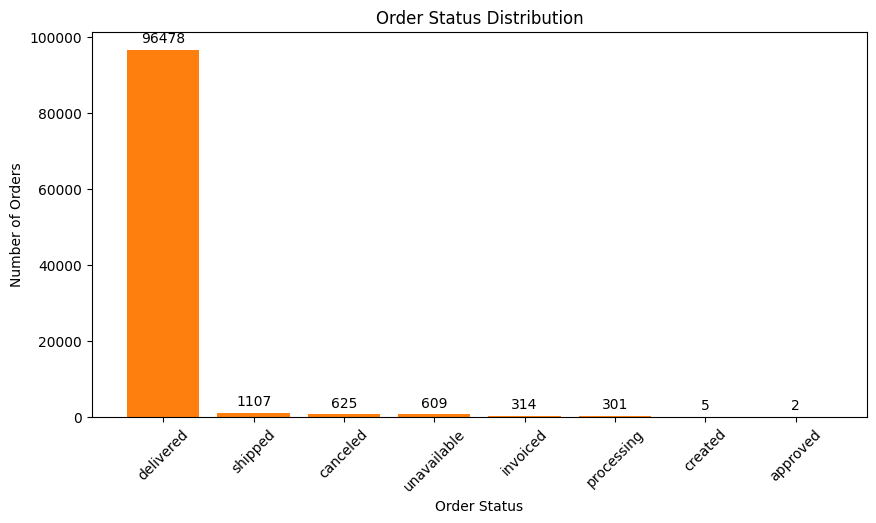

In [ ]:
# Order Status Distribution

order_status = orders["order_status"].value_counts()

plt.figure(figsize=(10, 5))

bars = plt.bar(order_status.index, order_status.values)
plt.bar_label(bars, padding=3)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

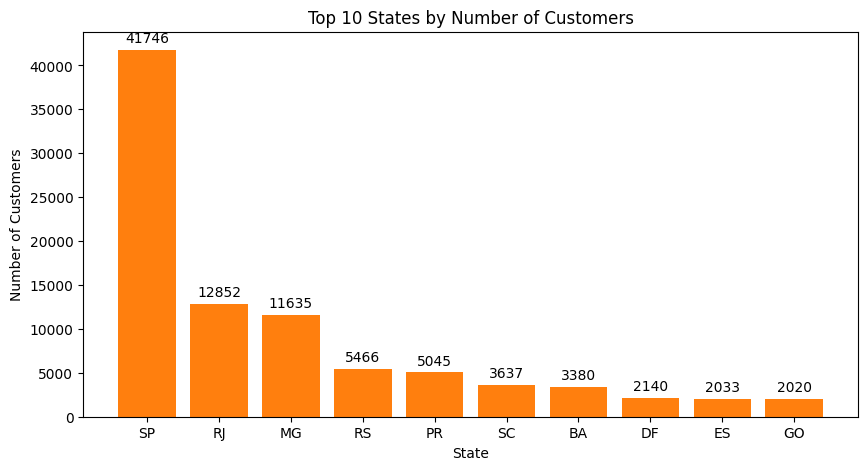

In [ ]:
# Top 10 Customer States
top_states = customers["customer_state"].value_counts().head(10)

plt.figure(figsize=(10, 5))

bars = plt.bar(top_states.index, top_states.values)
plt.bar_label(bars, padding=3)

plt.title("Top 10 States by Number of Customers")
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.show()

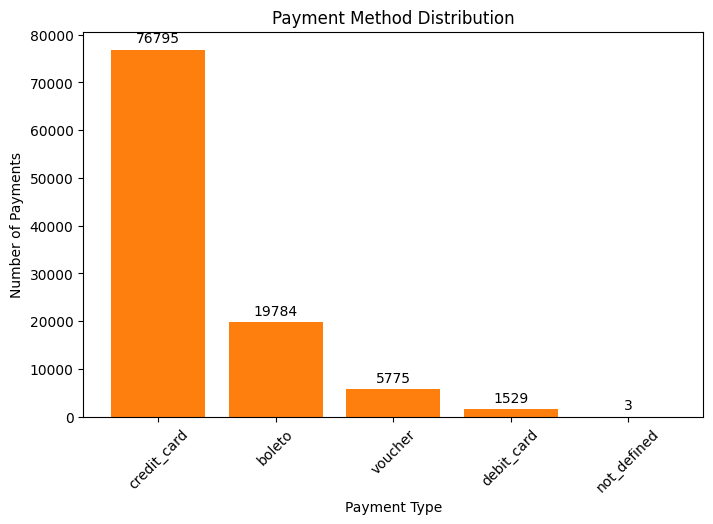

In [ ]:
# Payment Method Distribution
payment_type = payments["payment_type"].value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(payment_type.index, payment_type.values)
plt.bar_label(bars, padding=3)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")

plt.xticks(rotation=45)

plt.show()

# Order Analysis

In [51]:
# Basic Order Analysis

print("Total Orders:", orders["order_id"].nunique())

print("\nOrder Status Distribution:")
print(orders["order_status"].value_counts())

print("\nOrder Status Percentage:")
print(
    (orders["order_status"]
     .value_counts(normalize=True) * 100)
    .round(2)
)

Total Orders: 99441

Order Status Distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Order Status Percentage:
order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64


## Order Trend Over Time

In [52]:
# Create time-based columns
# Before analyzing time create useful date columns from the purchase date.

orders["purchase_year"] = orders["order_purchase_timestamp"].dt.year

orders["purchase_month"] = orders["order_purchase_timestamp"].dt.month

orders["purchase_month_name"] = orders[
    "order_purchase_timestamp"
].dt.month_name()

orders["purchase_day"] = orders["order_purchase_timestamp"].dt.day

orders["purchase_day_name"] = orders[
    "order_purchase_timestamp"
].dt.day_name()

orders["purchase_hour"] = orders[
    "order_purchase_timestamp"
].dt.hour

In [53]:
# Monthly Order Analysis
# Orders by month

monthly_orders = (
    orders
    .groupby(
        orders["order_purchase_timestamp"]
        .dt.to_period("M")
    )["order_id"]
    .nunique()
)

print(monthly_orders)

# This tells us how many unique orders were placed every month.

order_purchase_timestamp
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64


In [54]:
# Orders by Day of Week
# Define correct weekday order

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

orders_by_day = (
    orders["purchase_day_name"]
    .value_counts()
    .reindex(day_order)
)

print(orders_by_day)

# This helps us find which day customers shop the most.

purchase_day_name
Monday       16196
Tuesday      15963
Wednesday    15552
Thursday     14761
Friday       14122
Saturday     10887
Sunday       11960
Name: count, dtype: int64


In [55]:
# Orders by hour

orders_by_hour = (
    orders["purchase_hour"]
    .value_counts()
    .sort_index()
)

print(orders_by_hour)

# This shows what time of day customers place the most orders.

purchase_hour
0     2394
1     1170
2      510
3      272
4      206
5      188
6      502
7     1231
8     2967
9     4785
10    6177
11    6578
12    5995
13    6518
14    6569
15    6454
16    6675
17    6150
18    5769
19    5982
20    6193
21    6217
22    5816
23    4123
Name: count, dtype: int64


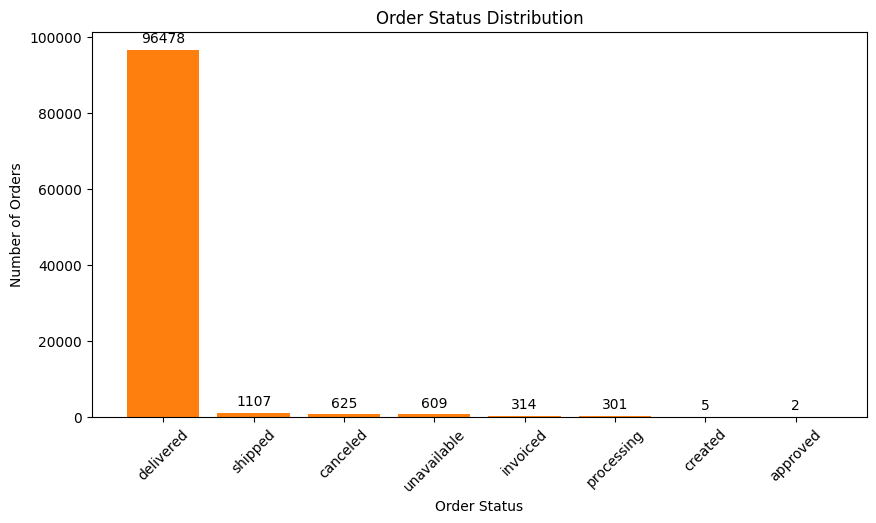

In [ ]:
# Order Status Distribution

order_status = orders["order_status"].value_counts()

plt.figure(figsize=(10, 5))

bars = plt.bar(order_status.index, order_status.values)
plt.bar_label(bars, padding=3)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

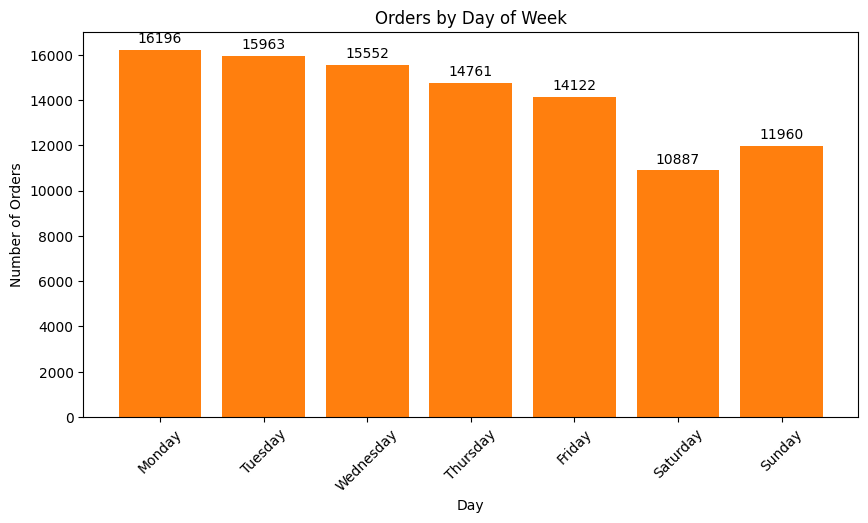

In [ ]:
# Orders by Day of Week
plt.figure(figsize=(10, 5))

bars = plt.bar(orders_by_day.index, orders_by_day.values)
plt.bar_label(bars, padding=3)

plt.title("Orders by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

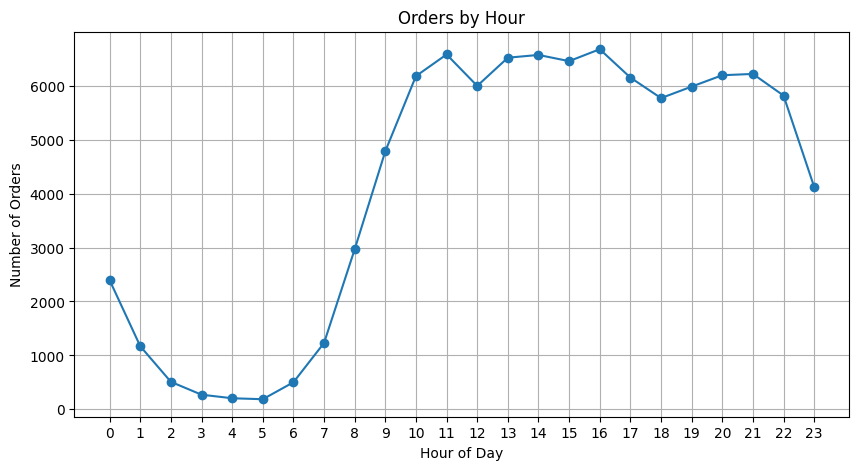

In [58]:
# Orders by Hour

plt.figure(figsize=(10, 5))

plt.plot(
    orders_by_hour.index,
    orders_by_hour.values,
    marker="o"
)

plt.title("Orders by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(range(24))

plt.grid()

plt.show()

# Sales & Revenue Analysis

In [59]:
# Total Revenue and Basic Sales KPIs

# Total Revenue

total_revenue = payments["payment_value"].sum()

# Revenue per order
order_revenue = (
    payments
    .groupby("order_id")["payment_value"]
    .sum()
    .reset_index()
    .rename(columns={"payment_value": "order_revenue"})
)

# Average Order Value
average_order_value = order_revenue["order_revenue"].mean()

# Highest Order Value
highest_order_value = order_revenue["order_revenue"].max()

print("Total Revenue:", round(total_revenue, 2))
print("Average Order Value:", round(average_order_value, 2))
print("Highest Order Value:", round(highest_order_value, 2))

Total Revenue: 16008872.12
Average Order Value: 160.99
Highest Order Value: 13664.08


In [60]:
# Monthly Revenue Trend
# Firstly, merge the order-level revenue with the order purchase date.

sales_data = orders[
    ["order_id", "order_purchase_timestamp", "order_status"]
].merge(
    order_revenue,
    on="order_id",
    how="inner"
)

# calculating monthly revenue

monthly_revenue = (
    sales_data
    .groupby(
        sales_data["order_purchase_timestamp"]
        .dt.to_period("M")
    )["order_revenue"]
    .sum()
)

print(monthly_revenue)

# This tells us: How much revenue did the business generate each month?

order_purchase_timestamp
2016-09        252.24
2016-10      59090.48
2016-12         19.62
2017-01     138488.04
2017-02     291908.01
2017-03     449863.60
2017-04     417788.03
2017-05     592918.82
2017-06     511276.38
2017-07     592382.92
2017-08     674396.32
2017-09     727762.45
2017-10     779677.88
2017-11    1194882.80
2017-12     878401.48
2018-01    1115004.18
2018-02     992463.34
2018-03    1159652.12
2018-04    1160785.48
2018-05    1153982.15
2018-06    1023880.50
2018-07    1066540.75
2018-08    1022425.32
2018-09       4439.54
2018-10        589.67
Freq: M, Name: order_revenue, dtype: float64


In [61]:
# Monthly Orders vs Revenue

monthly_sales_summary = (
    sales_data
    .groupby(
        sales_data["order_purchase_timestamp"]
        .dt.to_period("M")
    )
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("order_revenue", "sum")
    )
)

print(monthly_sales_summary)

                          total_orders  total_revenue
order_purchase_timestamp                             
2016-09                              3         252.24
2016-10                            324       59090.48
2016-12                              1          19.62
2017-01                            800      138488.04
2017-02                           1780      291908.01
2017-03                           2682      449863.60
2017-04                           2404      417788.03
2017-05                           3700      592918.82
2017-06                           3245      511276.38
2017-07                           4026      592382.92
2017-08                           4331      674396.32
2017-09                           4285      727762.45
2017-10                           4631      779677.88
2017-11                           7544     1194882.80
2017-12                           5673      878401.48
2018-01                           7269     1115004.18
2018-02                     

In [62]:
# Revenue by Customer State

state_revenue = (
    sales_data
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
    .merge(
        customers[
            ["customer_id", "customer_state"]
        ],
        on="customer_id",
        how="left"
    )
    .groupby("customer_state")["order_revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(state_revenue.head(10))

# This shows which customer states generated the most revenue.

customer_state
SP    5998226.96
RJ    2144379.69
MG    1872257.26
RS     890898.54
PR     811156.38
SC     623086.43
BA     616645.82
DF     355141.08
GO     350092.31
ES     325967.55
Name: order_revenue, dtype: float64


In [63]:
# Revenue by Product Category
# For this analysis, we should use items, because each item contains the product and its price.

category_sales = (
    items
    .merge(
        products[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        cat_translation,
        on="product_category_name",
        how="left"
    )
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales.head(10))

# This is because we want to know:
# Which product categories generated the highest product sales value?
# Payment values can include other amounts such as freight.

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64


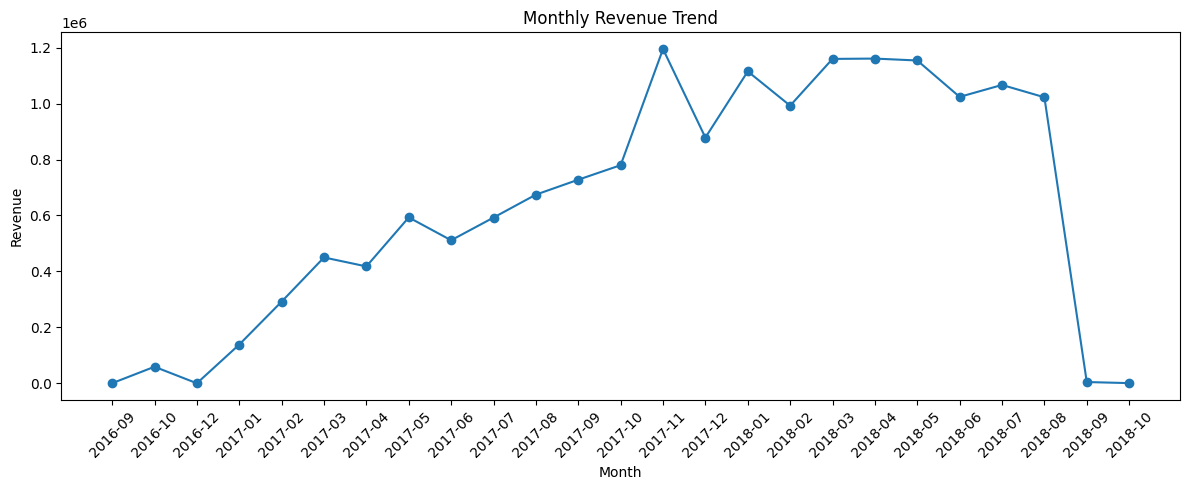

In [64]:
# Monthly Revenue Trend

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

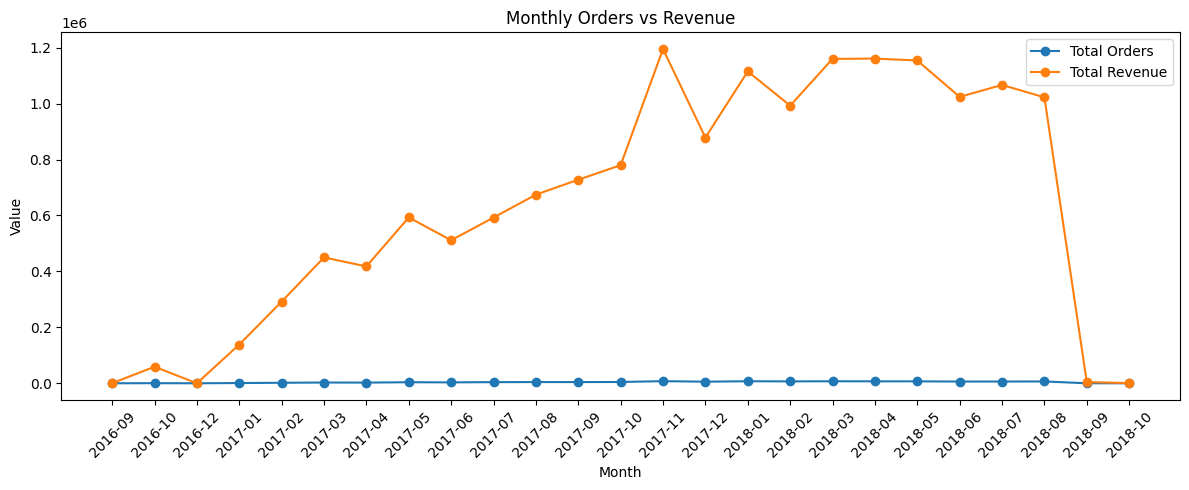

In [65]:
# Monthly Orders vs Revenue
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales_summary.index.astype(str),
    monthly_sales_summary["total_orders"],
    marker="o",
    label="Total Orders"
)

plt.plot(
    monthly_sales_summary.index.astype(str),
    monthly_sales_summary["total_revenue"],
    marker="o",
    label="Total Revenue"
)

plt.title("Monthly Orders vs Revenue")
plt.xlabel("Month")
plt.ylabel("Value")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

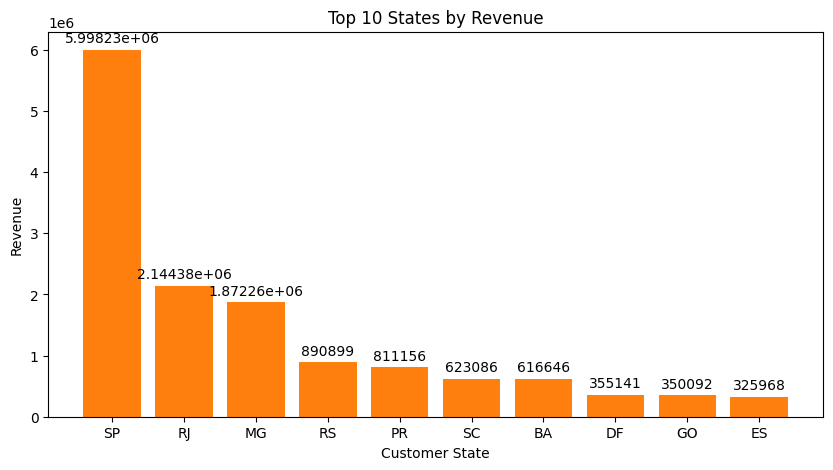

In [ ]:
# Top 10 States by Revenue

top_states_revenue = state_revenue.head(10)

plt.figure(figsize=(10, 5))

bars = plt.bar(top_states_revenue.index, top_states_revenue.values)
plt.bar_label(bars, padding=3)

plt.title("Top 10 States by Revenue")
plt.xlabel("Customer State")
plt.ylabel("Revenue")

plt.show()

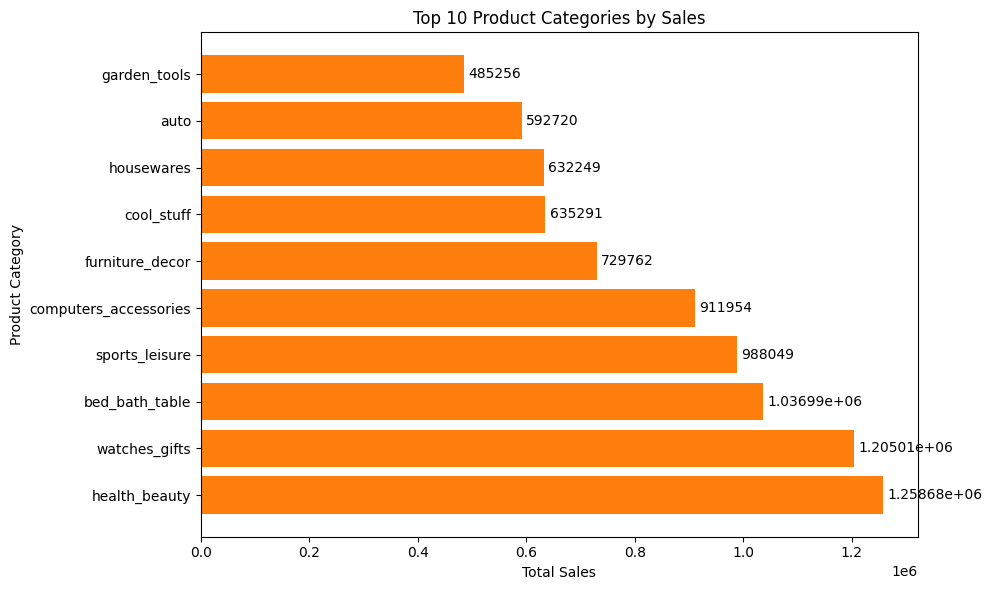

In [ ]:
# Top 10 Product Categories by Sales

top_categories = category_sales.head(10)

plt.figure(figsize=(10, 6))

bars = plt.barh(top_categories.index, top_categories.values)
plt.bar_label(bars, padding=3)

plt.title("Top 10 Product Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Category")

plt.tight_layout()

plt.show()

# Customer Analysis

In [68]:
# Basic Customer Overview

total_customers = customers["customer_unique_id"].nunique()

print("Total Unique Customers:", f"{total_customers:,}")

# This helps us identify whether the same person made multiple purchases.

Total Unique Customers: 96,096


In [69]:
# Repeat Customers

# Merge customers with orders

customer_orders = customers.merge(
    orders[["order_id", "customer_id"]],
    on="customer_id",
    how="inner"
)

# Count orders per unique customer

customer_order_count = (
    customer_orders
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

print(customer_order_count.head(10))

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
12f5d6e1cbf93dafd9dcc19095df0b3d     6
63cfc61cee11cbe306bff5857d00bfe4     6
dc813062e0fc23409cd255f7f53c7074     6
de34b16117594161a6a89c50b289d35a     6
Name: order_id, dtype: int64


In [70]:
# Customer purchase frequency

purchase_frequency = customer_order_count.value_counts().sort_index()

print(purchase_frequency.head(10))

# This tells us whether the business has mostly one-time customers or repeat customers.

order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64


In [71]:
# Calculate repeat customer rate

repeat_customers = (
    customer_order_count > 1
).sum()

repeat_customer_rate = (
    repeat_customers / total_customers
) * 100

print("Repeat Customers:", f"{repeat_customers:,}")
print("Repeat Customer Rate:", round(repeat_customer_rate, 2), "%")

Repeat Customers: 2,997
Repeat Customer Rate: 3.12 %


In [72]:
# Top 10 states by number of customers

top_customer_states = (
    customers["customer_state"]
    .value_counts()
    .head(10)
)

print(top_customer_states)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


In [73]:
# Top 10 cities by number of customers

top_customer_cities = (
    customers["customer_city"]
    .value_counts()
    .head(10)
)

print(top_customer_cities)

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64


In [74]:
# Customer spending analysis

customer_revenue = (
    customers[
        ["customer_id", "customer_unique_id"]
    ]
    .merge(
        orders[["order_id", "customer_id"]],
        on="customer_id",
        how="inner"
    )
    .merge(
        order_revenue,
        on="order_id",
        how="left"
    )
)

customer_total_spending = (
    customer_revenue
    .groupby("customer_unique_id")["order_revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(customer_total_spending.head(10))

# This calculates the total amount spent by each unique customer.

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13664.08
46450c74a0d8c5ca9395da1daac6c120     9553.02
da122df9eeddfedc1dc1f5349a1a690c     7571.63
763c8b1c9c68a0229c42c9fc6f662b93     7274.88
dc4802a71eae9be1dd28f5d788ceb526     6929.31
459bef486812aa25204be022145caa62     6922.21
ff4159b92c40ebe40454e3e6a7c35ed6     6726.66
4007669dec559734d6f53e029e360987     6081.54
5d0a2980b292d049061542014e8960bf     4809.44
eebb5dda148d3893cdaf5b5ca3040ccb     4764.34
Name: order_revenue, dtype: float64


In [75]:
# Average Customer Spending

average_customer_spending = (
    customer_total_spending.mean()
)

print(
    "Average Customer Spending:",
    round(average_customer_spending, 2)
)

Average Customer Spending: 166.59


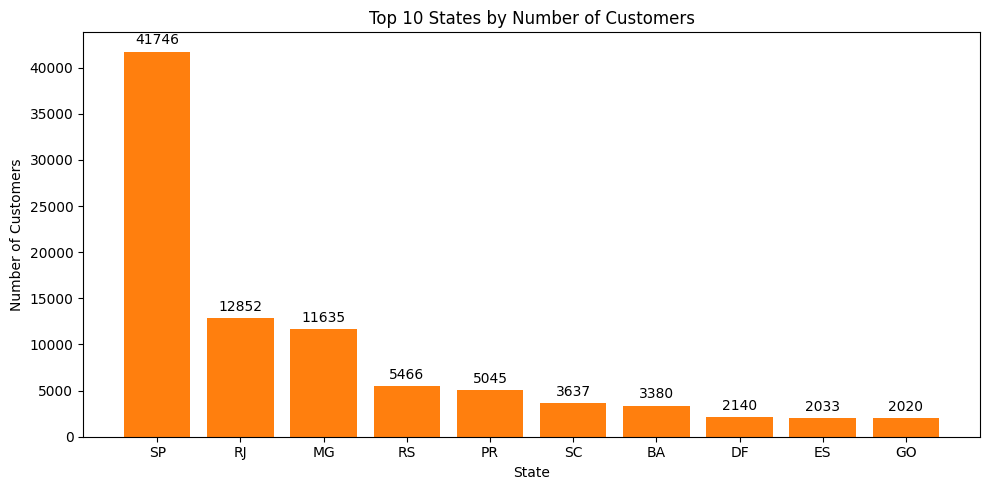

In [ ]:
# Top 10 States by Customers

plt.figure(figsize=(10, 5))

bars = plt.bar(top_customer_states.index, top_customer_states.values)
plt.bar_label(bars, padding=3)

plt.title("Top 10 States by Number of Customers")
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

# It shows which states have the largest customer base.

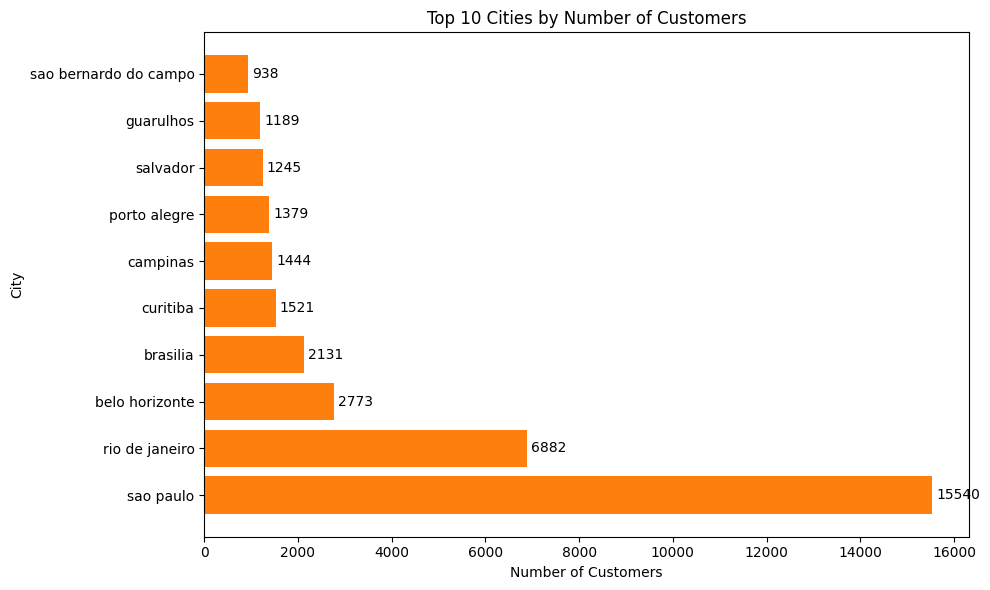

In [ ]:
# Top 10 Cities by Customers

plt.figure(figsize=(10, 6))

bars = plt.barh(top_customer_cities.index, top_customer_cities.values)
plt.bar_label(bars, padding=3)

plt.title("Top 10 Cities by Number of Customers")
plt.xlabel("Number of Customers")
plt.ylabel("City")

plt.tight_layout()

plt.show()

# This helps identify the cities where the platform is most popular.

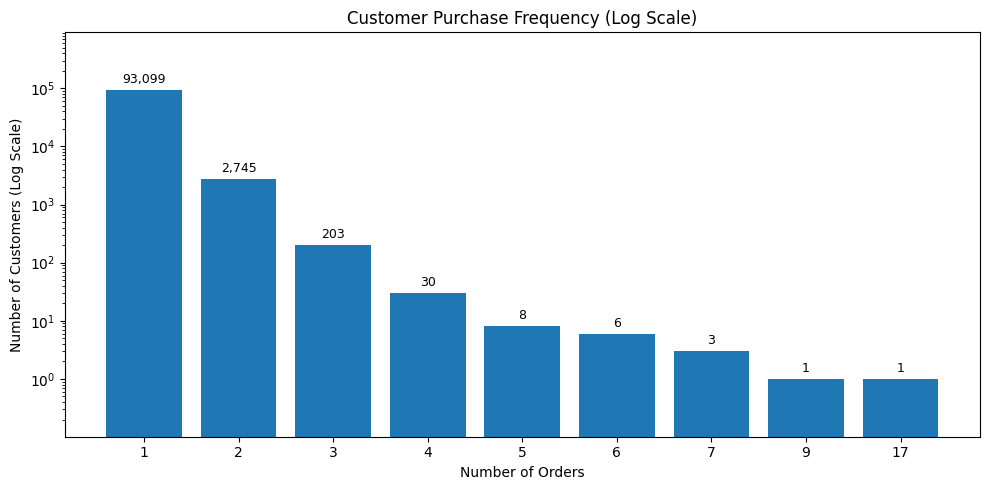

In [78]:
# Customer Purchase Frequency

plt.figure(figsize=(10, 5))

bars = plt.bar(
    purchase_frequency.index.astype(str),
    purchase_frequency.values
)

plt.yscale("log")

plt.bar_label(bars, labels=[f"{v:,}" for v in purchase_frequency.values], padding=3, fontsize=9)

plt.title("Customer Purchase Frequency (Log Scale)")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers (Log Scale)")

plt.margins(y=0.2)

plt.tight_layout()
plt.show()

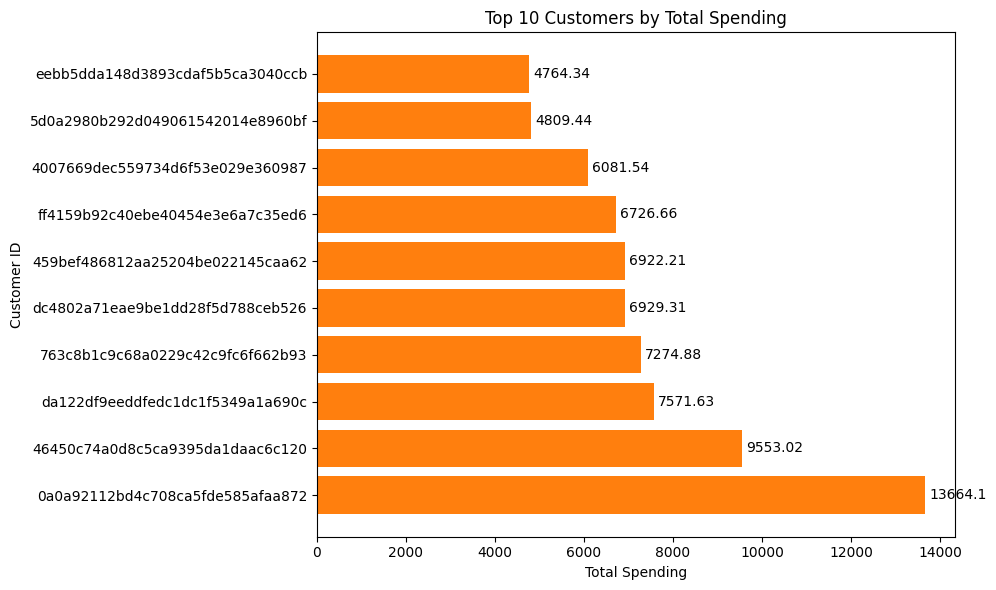

In [ ]:
# Top 10 Customers by Total Spending

top_customers_spending = customer_total_spending.head(10)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_customers_spending.index.astype(str),
    top_customers_spending.values
)   
plt.bar_label(bars, padding=3)

plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Total Spending")
plt.ylabel("Customer ID")

plt.tight_layout()

plt.show()

# Product Analysis

In [80]:
# Create product analysis dataset

product_data = (
    items
    .merge(
        products[
            [
                "product_id",
                "product_category_name",
                "product_weight_g"
            ]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        cat_translation,
        on="product_category_name",
        how="left"
    )
)

product_data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_weight_g,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,650.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,30000.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,3050.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,200.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,3750.0,garden_tools


In [81]:
# Top Product Categories by Quantity Sold
# Top categories by quantity sold

category_quantity = (
    product_data
    .groupby("product_category_name_english")
    .size()
    .sort_values(ascending=False)
)

print(category_quantity.head(10))

product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
dtype: int64


In [82]:
# Top categories by product revenue

category_revenue = (
    product_data
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue.head(10))

# This tells us which categories generated the highest product sales value.
# We use price here, not payment_value, because we are analyzing product sales.

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64


In [83]:
# Average product price by category

average_category_price = (
    product_data
    .groupby("product_category_name_english")["price"]
    .mean()
    .sort_values(ascending=False)
)

print(average_category_price.head(10))

# This helps us identify premium or expensive categories.

product_category_name_english
computers                                         1098.340542
small_appliances_home_oven_and_coffee              624.285658
home_appliances_2                                  476.124958
agro_industry_and_commerce                         342.124858
musical_instruments                                281.616000
small_appliances                                   280.778468
Portable Kitchen Appliances and Food Preparers     264.568667
fixed_telephony                                    225.693182
construction_tools_safety                          208.992371
watches_gifts                                      201.135984
Name: price, dtype: float64


In [84]:
# Top products by quantity sold

top_products_quantity = (
    product_data
    .groupby("product_id")
    .size()
    .sort_values(ascending=False)
)

print(top_products_quantity.head(10))

# This shows which specific products were purchased the most.

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
dtype: int64


In [85]:
# Top products by revenue

top_products_revenue = (
    product_data
    .groupby("product_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

print(top_products_revenue.head(10))

# This is useful because the most sold product is not always the product generating the most revenue.

product_id
bb50f2e236e5eea0100680137654686c    63885.00
6cdd53843498f92890544667809f1595    54730.20
d6160fb7873f184099d9bc95e30376af    48899.34
d1c427060a0f73f6b889a5c7c61f2ac4    47214.51
99a4788cb24856965c36a24e339b6058    43025.56
3dd2a17168ec895c781a9191c1e95ad7    41082.60
25c38557cf793876c5abdd5931f922db    38907.32
5f504b3a1c75b73d6151be81eb05bdc9    37733.90
53b36df67ebb7c41585e8d54d6772e08    37683.42
aca2eb7d00ea1a7b8ebd4e68314663af    37608.90
Name: price, dtype: float64


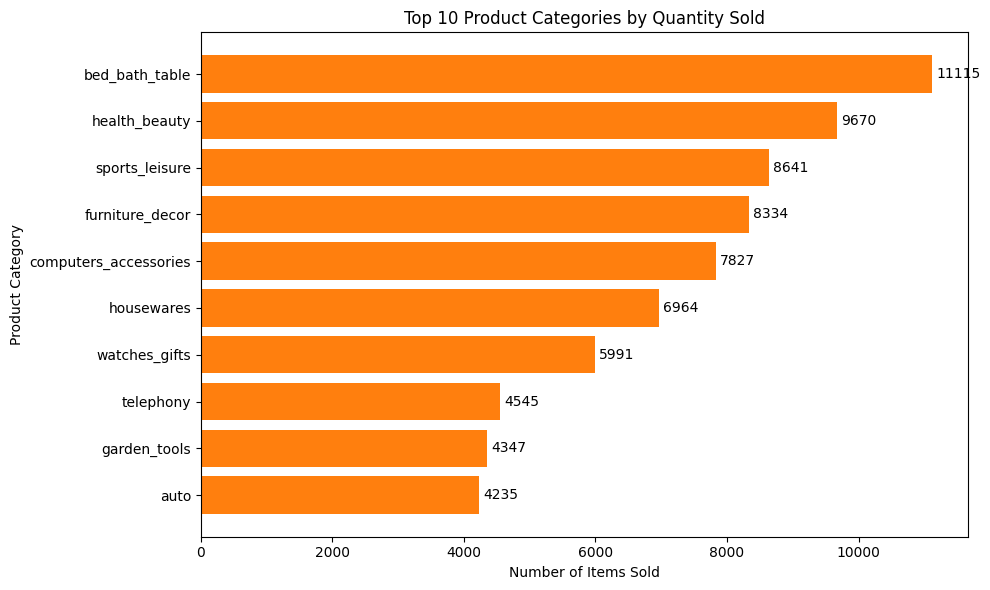

In [ ]:
# Top 10 Categories by Quantity Sold
top_category_quantity = category_quantity.head(10).sort_values()

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_category_quantity.index,
    top_category_quantity.values
)
plt.bar_label(bars, padding=3)

plt.title("Top 10 Product Categories by Quantity Sold")
plt.xlabel("Number of Items Sold")
plt.ylabel("Product Category")

plt.tight_layout()

plt.show()

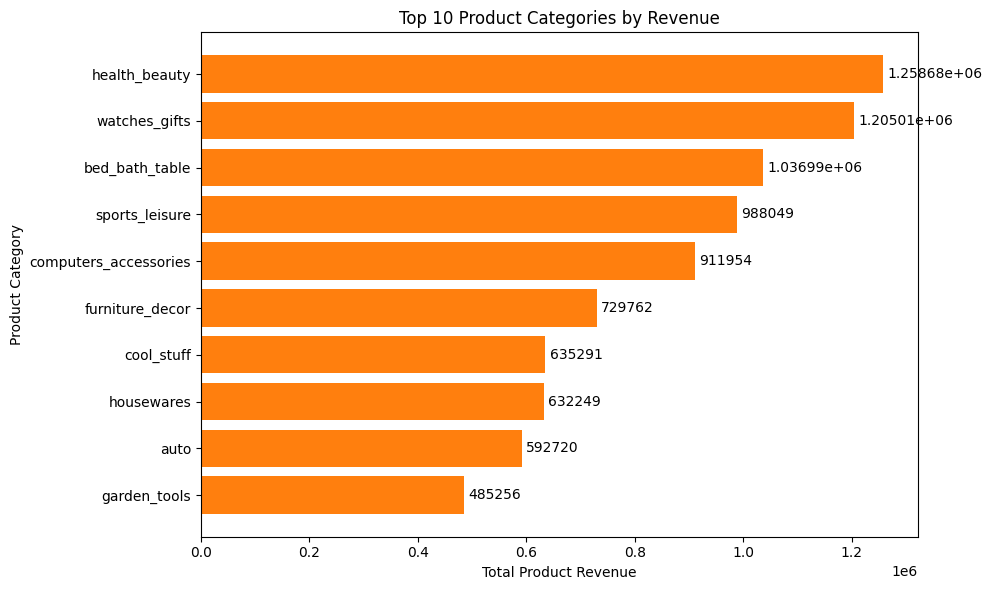

In [ ]:
# Top 10 Categories by Revenue
top_category_revenue = category_revenue.head(10).sort_values()

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_category_revenue.index,
    top_category_revenue.values
)
plt.bar_label(bars, padding=3)


plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Total Product Revenue")
plt.ylabel("Product Category")

plt.tight_layout()

plt.show()

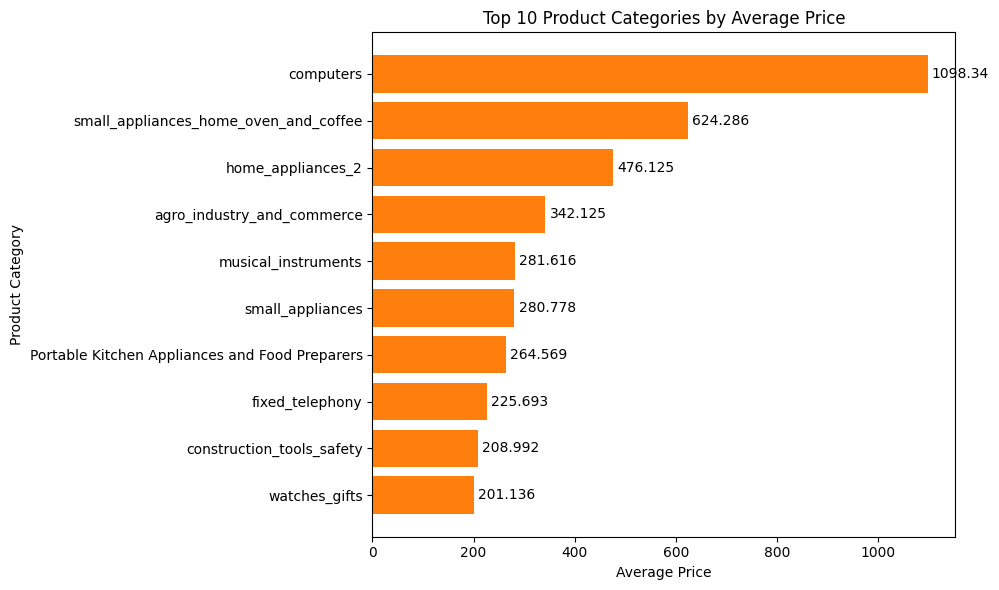

In [ ]:
# Top 10 Categories by Average Price

top_average_price = average_category_price.head(10).sort_values()

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_average_price.index,
    top_average_price.values
)
plt.bar_label(bars, padding=3)

plt.title("Top 10 Product Categories by Average Price")
plt.xlabel("Average Price")
plt.ylabel("Product Category")

plt.tight_layout()

plt.show()

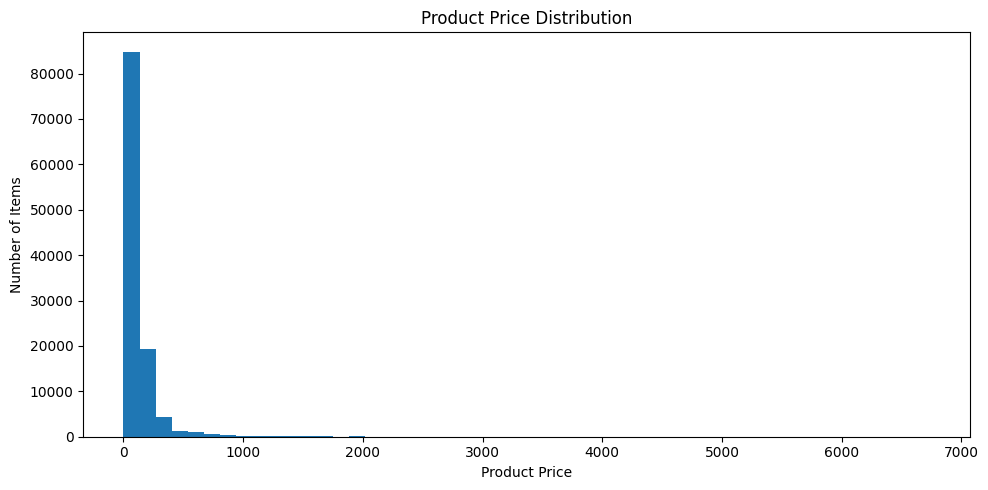

In [ ]:
# Price Distribution
plt.figure(figsize=(10, 5))

plt.hist(
    product_data["price"],
    bins=50
)

plt.title("Product Price Distribution")
plt.xlabel("Product Price")
plt.ylabel("Number of Items")

plt.tight_layout()

plt.show()

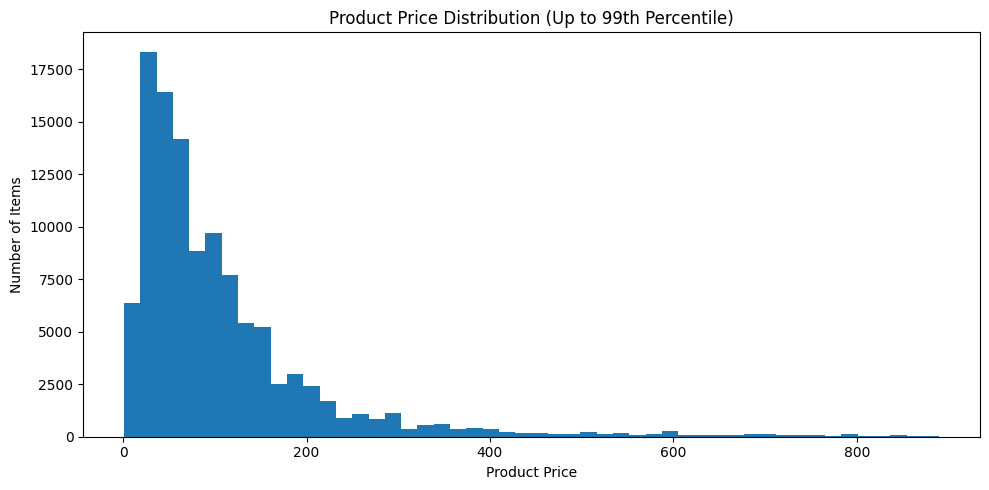

In [90]:
# dataset has some expensive product outliers, the chart may be heavily skewed. If that happens, limit the visualization without deleting the data

price_limit = product_data["price"].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    product_data.loc[
        product_data["price"] <= price_limit,
        "price"
    ],
    bins=50
)

plt.title("Product Price Distribution (Up to 99th Percentile)")
plt.xlabel("Product Price")
plt.ylabel("Number of Items")

plt.tight_layout()

plt.show()

# We are not removing outliers from the dataset. We are only limiting the chart so that the distribution of most products is easier to see.


# Seller Analysis

In [91]:
# Create seller analysis dataset

seller_data = (
    items
    .merge(
        sellers,
        on="seller_id",
        how="left"
    )
)

seller_data.head()

# After merging, we can analyze seller sales and location performance.

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,37564,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,14403,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,87900,loanda,PR


In [92]:
# Basic Seller Overview

total_sellers = sellers["seller_id"].nunique()

print("Total Sellers:", f"{total_sellers:,}")

Total Sellers: 3,095


In [93]:
# Top sellers by number of items sold

seller_quantity = (
    seller_data
    .groupby("seller_id")
    .size()
    .sort_values(ascending=False)
)

print(seller_quantity.head(10))

# Each row in items represents an item sold in an order.
# So .size() counts how many items each seller sold.

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
dtype: int64


In [94]:
# Top sellers by product revenue

seller_revenue = (
    seller_data
    .groupby("seller_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

print(seller_revenue.head(10))

# We use price because we want to measure the value of products sold by each seller.

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64


In [ ]:
# Average Revenue per Seller

average_seller_revenue = seller_revenue.mean()

print(
    "Average Revenue per Seller:",
    round(average_seller_revenue, 2)
)

# This helps us understand the average sales performance of sellers.

Average Revenue per Seller: 4391.48


In [96]:
# Top States by Number of Sellers
# Number of sellers in each state

seller_state_count = (
    sellers["seller_state"]
    .value_counts()
    .sort_values(ascending=False)
)

print(seller_state_count.head(10))

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: count, dtype: int64


In [97]:
# Revenue generated by sellers from each state

seller_state_revenue = (
    seller_data
    .groupby("seller_state")["price"]
    .sum()
    .sort_values(ascending=False)
)

print(seller_state_revenue.head(10))

# helps answer: Which seller locations generate the highest product sales?

seller_state
SP    8753396.21
PR    1261887.21
MG    1011564.74
RJ     843984.22
SC     632426.07
RS     378559.54
BA     285561.56
DF      97749.48
PE      91493.85
GO      66399.21
Name: price, dtype: float64


In [ ]:
# Seller Performance Comparison
# Now we can compare quantity sold vs revenue.

seller_performance = (
    seller_data
    .groupby("seller_id")
    .agg(
        items_sold=("order_item_id", "count"),
        total_revenue=("price", "sum"),
        average_product_price=("price", "mean")
    )
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

print(seller_performance.head(10))

# This is useful because:

# A seller may sell many cheap products
# Another seller may sell fewer expensive products

                                  items_sold  total_revenue  \
seller_id                                                     
4869f7a5dfa277a7dca6462dcf3b52b2        1156      229472.63   
53243585a1d6dc2643021fd1853d8905         410      222776.05   
4a3ca9315b744ce9f8e9374361493884        1987      200472.92   
fa1c13f2614d7b5c4749cbc52fecda94         586      194042.03   
7c67e1448b00f6e969d365cea6b010ab        1364      187923.89   
7e93a43ef30c4f03f38b393420bc753a         340      176431.87   
da8622b14eb17ae2831f4ac5b9dab84a        1551      160236.57   
7a67c85e85bb2ce8582c35f2203ad736        1171      141745.53   
1025f0e2d44d7041d6cf58b6550e0bfa        1428      138968.55   
955fee9216a65b617aa5c0531780ce60        1499      135171.70   

                                  average_product_price  
seller_id                                                
4869f7a5dfa277a7dca6462dcf3b52b2             198.505735  
53243585a1d6dc2643021fd1853d8905             543.356220  
4a3ca9315b7

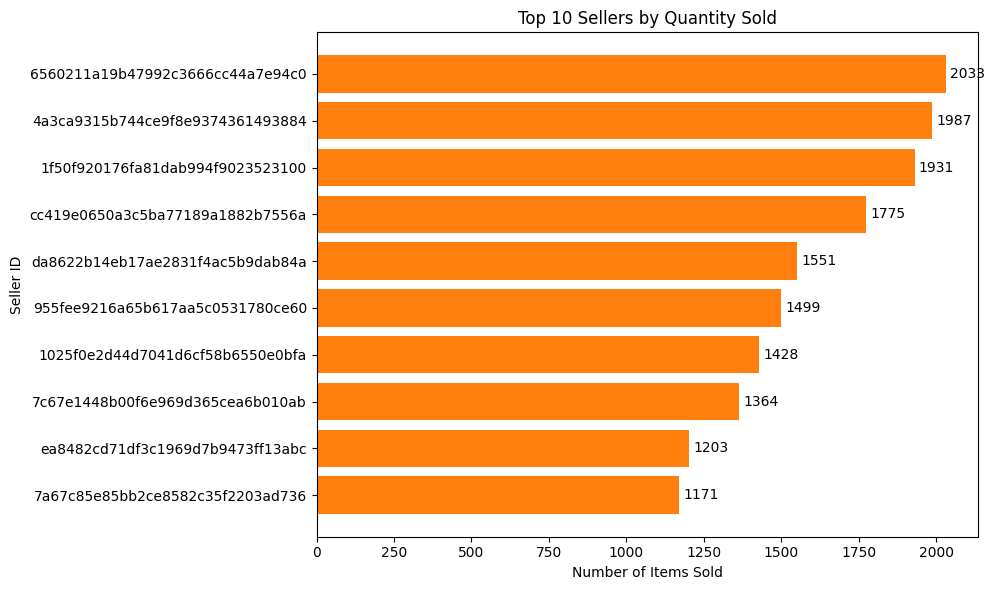

In [ ]:
# Top 10 Sellers by Quantity Sold
top_sellers_quantity = seller_quantity.head(10).sort_values()

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_sellers_quantity.index.astype(str),
    top_sellers_quantity.values
)
plt.bar_label(bars, padding=3)

plt.title("Top 10 Sellers by Quantity Sold")
plt.xlabel("Number of Items Sold")
plt.ylabel("Seller ID")

plt.tight_layout()

plt.show()

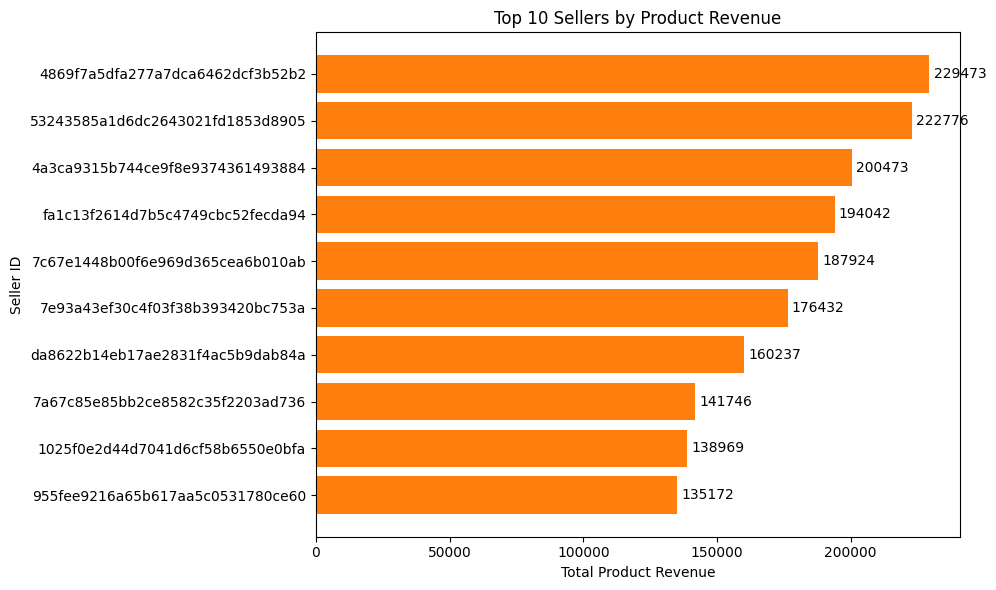

In [ ]:
# Top 10 Sellers by Revenue

top_sellers_revenue = seller_revenue.head(10).sort_values()

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_sellers_revenue.index.astype(str),
    top_sellers_revenue.values
)
plt.bar_label(bars, padding=3)

plt.title("Top 10 Sellers by Product Revenue")
plt.xlabel("Total Product Revenue")
plt.ylabel("Seller ID")

plt.tight_layout()

plt.show()

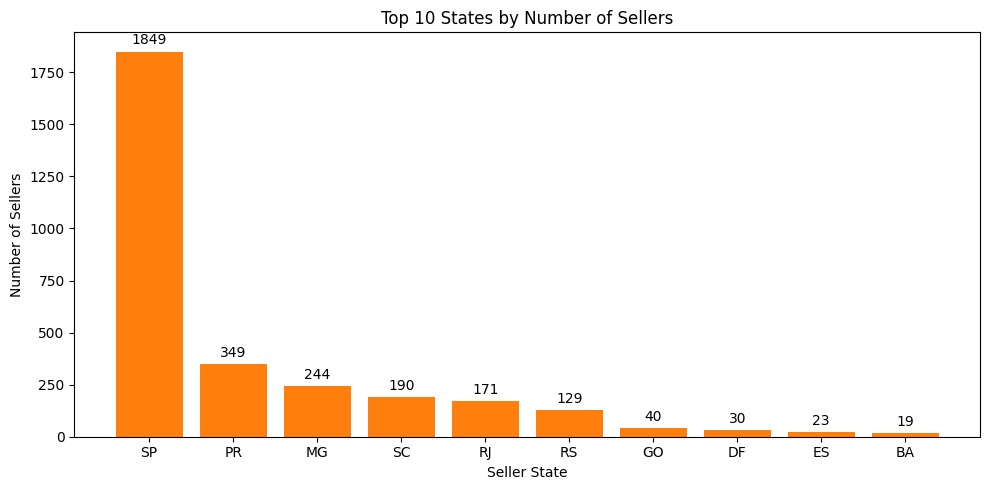

In [ ]:
# Top 10 States by Number of Sellers

top_seller_states = seller_state_count.head(10)

plt.figure(figsize=(10, 5))

bars = plt.bar(top_seller_states.index, top_seller_states.values)
plt.bar_label(bars, padding=3)

plt.title("Top 10 States by Number of Sellers")
plt.xlabel("Seller State")
plt.ylabel("Number of Sellers")

plt.tight_layout()

plt.show()

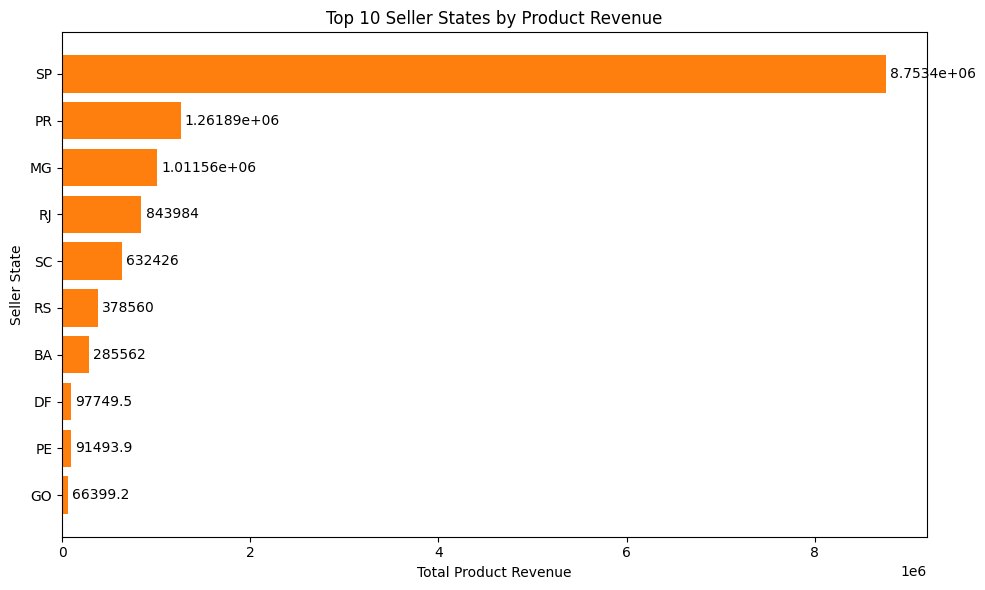

In [ ]:
# Top 10 Seller States by Revenue

top_seller_state_revenue = seller_state_revenue.head(10).sort_values()

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_seller_state_revenue.index,
    top_seller_state_revenue.values
)
plt.bar_label(bars, padding=3)

plt.title("Top 10 Seller States by Product Revenue")
plt.xlabel("Total Product Revenue")
plt.ylabel("Seller State")

plt.tight_layout()

plt.show()

# Payment Analysis

In [105]:
# Basic Payment Overview

total_payment_records = len(payments)

total_payment_value = payments["payment_value"].sum()

average_payment_value = payments["payment_value"].mean()

print("Total Payment Records:", f"{total_payment_records:,}")
print("Total Payment Value:", round(total_payment_value, 2))
print("Average Payment Value:", round(average_payment_value, 2))

Total Payment Records: 103,886
Total Payment Value: 16008872.12
Average Payment Value: 154.1


In [106]:
# Payment method usage

payment_method_count = (
    payments["payment_type"]
    .value_counts()
)

print(payment_method_count)

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


In [107]:
# Total payment value by payment type

payment_type_revenue = (
    payments
    .groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

print(payment_type_revenue)

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64


In [108]:
# Average payment value by payment type

average_payment_by_type = (
    payments
    .groupby("payment_type")["payment_value"]
    .mean()
    .sort_values(ascending=False)
)

print(average_payment_by_type)

payment_type
credit_card    163.319021
boleto         145.034435
debit_card     142.570170
voucher         65.703354
not_defined      0.000000
Name: payment_value, dtype: float64


In [109]:
# Installment distribution

installment_distribution = (
    payments["payment_installments"]
    .value_counts()
    .sort_index()
)

print(installment_distribution)

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64


In [111]:
# Average payment value by number of installments

installment_payment_value = (
    payments
    .groupby("payment_installments")["payment_value"]
    .mean()
    .sort_index()
)

print(installment_payment_value)

# This helps us understand whether customers making larger purchases tend to choose more installments.

payment_installments
0      94.315000
1     112.420229
2     127.228150
3     142.539317
4     163.976840
5     183.465222
6     209.849952
7     187.673672
8     307.737427
9     203.440870
10    415.085837
11    124.932174
12    321.678496
13    150.462500
14    167.962667
15    445.553108
16    292.694000
17    174.602500
18    486.483333
20    615.801765
21    243.700000
22    228.710000
23    236.480000
24    610.048889
Name: payment_value, dtype: float64


In [112]:
# Payment method summary

payment_summary = (
    payments
    .groupby("payment_type")
    .agg(
        transaction_count=("payment_type", "count"),
        total_payment_value=("payment_value", "sum"),
        average_payment_value=("payment_value", "mean")
    )
    .sort_values(
        "total_payment_value",
        ascending=False
    )
)

print(payment_summary)

              transaction_count  total_payment_value  average_payment_value
payment_type                                                               
credit_card               76795          12542084.19             163.319021
boleto                    19784           2869361.27             145.034435
voucher                    5775            379436.87              65.703354
debit_card                 1529            217989.79             142.570170
not_defined                   3                 0.00               0.000000


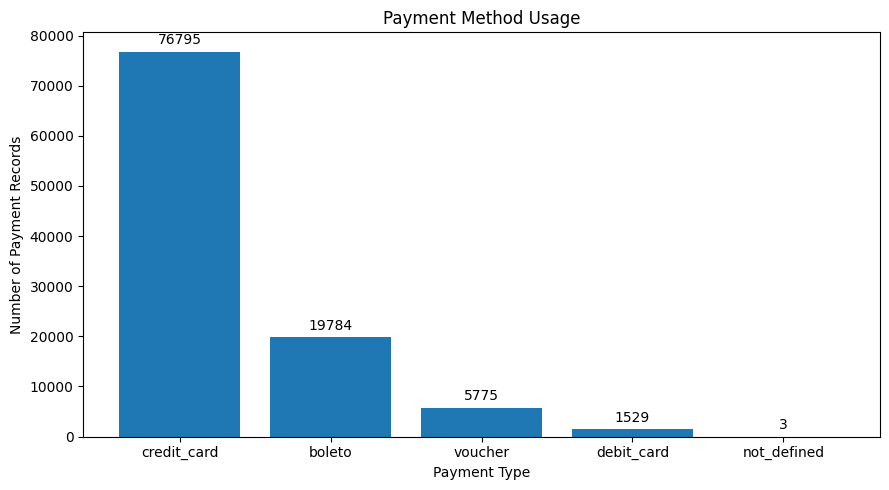

In [114]:
# Payment Method Usage

plt.figure(figsize=(9, 5))

bars = plt.bar(
    payment_method_count.index,
    payment_method_count.values
)
plt.bar_label(bars, padding=3)

plt.title("Payment Method Usage")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payment Records")

plt.tight_layout()

plt.show()

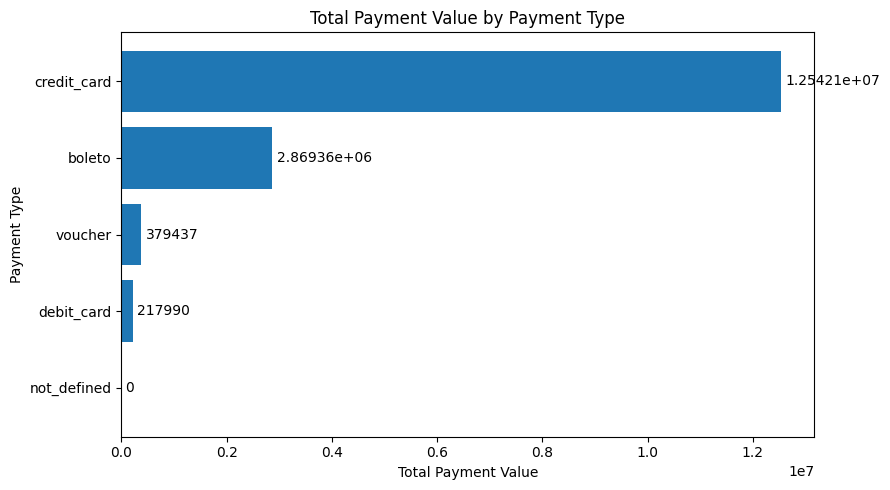

In [117]:
# Total Payment Value by Payment Type
payment_type_revenue_sorted = payment_type_revenue.sort_values()

plt.figure(figsize=(9, 5))

bars = plt.barh(
    payment_type_revenue_sorted.index,
    payment_type_revenue_sorted.values
)
plt.bar_label(bars, padding=3)

plt.title("Total Payment Value by Payment Type")
plt.xlabel("Total Payment Value")
plt.ylabel("Payment Type")

plt.tight_layout()

plt.show()

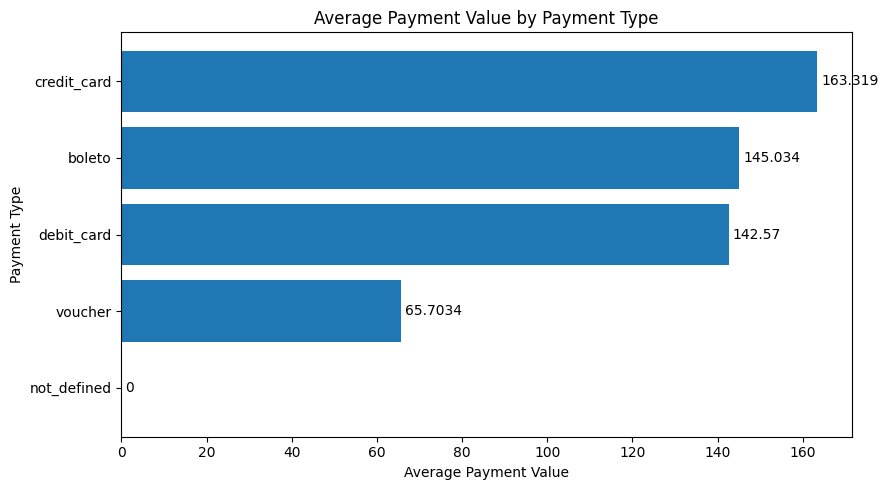

In [118]:
# Average Payment Value by Payment Type
average_payment_sorted = average_payment_by_type.sort_values()

plt.figure(figsize=(9, 5))

bars = plt.barh(
    average_payment_sorted.index,
    average_payment_sorted.values
)
plt.bar_label(bars, padding=3)

plt.title("Average Payment Value by Payment Type")
plt.xlabel("Average Payment Value")
plt.ylabel("Payment Type")

plt.tight_layout()

plt.show()

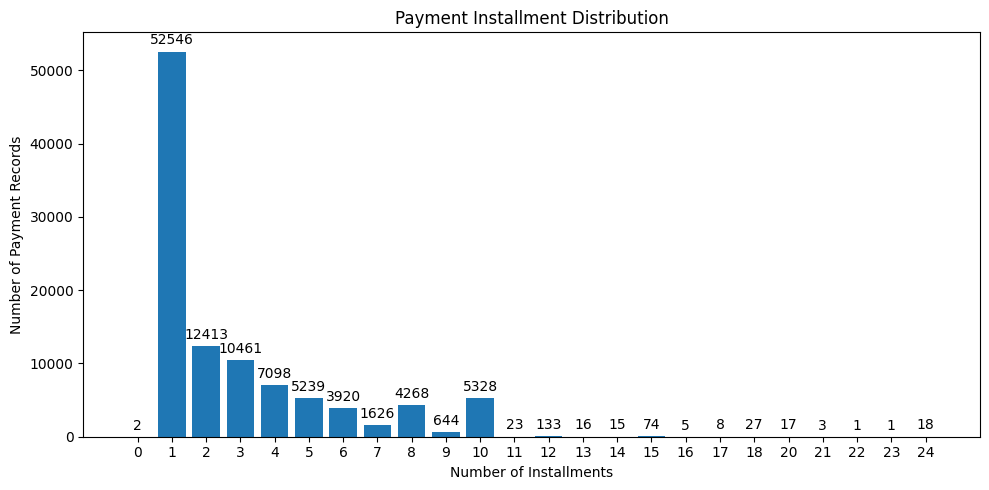

In [121]:
# Installment Distribution
# Because installment 0 exists in data, it is better to separate it from normal installment values when interpreting the chart.

installment_counts = (
    payments["payment_installments"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    installment_counts.index.astype(str),
    installment_counts.values
)
plt.bar_label(bars, padding=3)

plt.title("Payment Installment Distribution")
plt.xlabel("Number of Installments")
plt.ylabel("Number of Payment Records")

plt.tight_layout()

plt.show()

# Delivery Analysis

In [ ]:
# Create Delivery Analysis Dataset
delivery_data = (
    orders[
        [
            "order_id",
            "customer_id",
            "order_status",
            "order_purchase_timestamp",
            "order_delivered_carrier_date",
            "order_delivered_customer_date",
            "order_estimated_delivery_date"
        ]
    ]
    .merge(
        customers[
            [
                "customer_id",
                "customer_state",
                "customer_city"
            ]
        ],
        on="customer_id",
        how="left"
    )
)

delivery_data.head()

# This gives us both delivery information and the customer's location.

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,GO,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,RN,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,SP,santo andre


In [123]:
# Calculate Delivery Time
# We calculate the number of days between: Purchase Date → Customer Delivery Date

delivery_data["delivery_time_days"] = (
    delivery_data["order_delivered_customer_date"]
    - delivery_data["order_purchase_timestamp"]
).dt.total_seconds() / 86400

delivery_data["delivery_time_days"] = (
    delivery_data["delivery_time_days"].round(2)
)

print(
    delivery_data["delivery_time_days"].describe()
)

count    96476.000000
mean        12.558687
std          9.546528
min          0.530000
25%          6.770000
50%         10.220000
75%         15.720000
max        209.630000
Name: delivery_time_days, dtype: float64


In [ ]:
# Average Delivery Time
average_delivery_time = (
    delivery_data["delivery_time_days"]
    .mean()
)

median_delivery_time = (
    delivery_data["delivery_time_days"]
    .median()
)

print(
    "Average Delivery Time:",
    round(average_delivery_time, 2),
    "days"
)

print(
    "Median Delivery Time:",
    round(median_delivery_time, 2),
    "days"
)

# Some orders may have extremely long delivery times, which can affect the average.
# The median gives us a better idea of the typical delivery experience.

Average Delivery Time: 12.56 days
Median Delivery Time: 10.22 days


In [125]:
# Calculate Estimated vs Actual Delivery

delivery_data["delivery_difference_days"] = (
    delivery_data["order_delivered_customer_date"]
    - delivery_data["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

delivery_data["delivery_difference_days"] = (
    delivery_data["delivery_difference_days"].round(2)
)

delivery_data[
    [
        "delivery_time_days",
        "delivery_difference_days"
    ]
].head()

,delivery_time_days,delivery_difference_days
0,8.44,-7.11
1,13.78,-5.36
2,9.39,-17.25
3,13.21,-12.98
4,2.87,-9.24


In [126]:
# Count Early and Late Deliveries

delivery_data["delivery_status"] = np.where(
    delivery_data["delivery_difference_days"] > 0,
    "Late",
    "On Time / Early"
)

delivery_status_count = (
    delivery_data["delivery_status"]
    .value_counts()
)

print(delivery_status_count)

delivery_status
On Time / Early    91620
Late                7821
Name: count, dtype: int64


In [ ]:
# Late Delivery Rate

late_delivery_rate = (
    delivery_data["delivery_status"]
    .eq("Late")
    .mean()
    * 100
)

print(
    "Late Delivery Rate:",
    round(late_delivery_rate, 2),
    "%"
)

# This tells us what percentage of delivered orders arrived after the estimated delivery date.

Late Delivery Rate: 7.86 %


In [ ]:
# Delivery Time by Customer State
state_delivery_time = (
    delivery_data
    .groupby("customer_state")["delivery_time_days"]
    .mean()
    .sort_values(ascending=False)
)

print(state_delivery_time.head(10))

# This helps us identify which customer states experience the slowest deliveries.

customer_state
RR    29.386829
AP    27.185224
AM    26.425862
AL    24.544005
PA    23.772970
MA    21.573138
SE    21.519701
CE    21.266575
AC    21.035250
PB    20.426615
Name: delivery_time_days, dtype: float64


In [129]:
# Delivery Performance Summary
delivery_summary = (
    delivery_data
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "count"),
        average_delivery_days=("delivery_time_days", "mean"),
        median_delivery_days=("delivery_time_days", "median"),
        late_delivery_rate=(
            "delivery_status",
            lambda x: (x == "Late").mean() * 100
        )
    )
    .sort_values(
        "average_delivery_days",
        ascending=False
    )
)

print(delivery_summary.head(10))

                total_orders  average_delivery_days  median_delivery_days  \
customer_state                                                              
RR                        46              29.386829                25.010   
AP                        68              27.185224                24.350   
AM                       148              26.425862                25.880   
AL                       413              24.544005                22.330   
PA                       975              23.772970                21.075   
MA                       747              21.573138                19.190   
SE                       350              21.519701                18.010   
CE                      1336              21.266575                18.210   
AC                        81              21.035250                18.355   
PB                       536              20.426615                18.150   

                late_delivery_rate  
customer_state                      
R

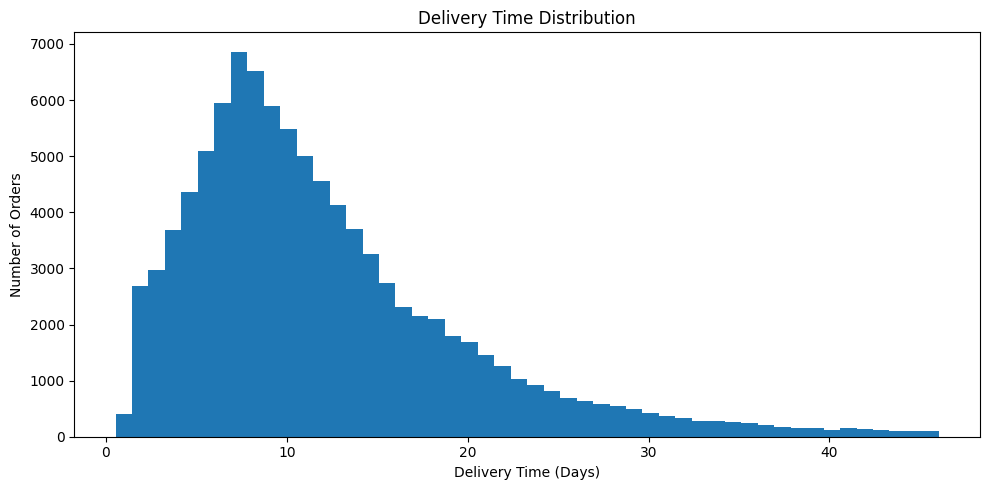

In [ ]:
# Delivery Time Distribution

delivery_time_limit = (
    delivery_data["delivery_time_days"]
    .quantile(0.99)
)

plt.figure(figsize=(10, 5))

plt.hist(
    delivery_data.loc[
        delivery_data["delivery_time_days"] <= delivery_time_limit,
        "delivery_time_days"
    ],
    bins=50
)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

# We use the 99th percentile only for the chart so extremely long delivery times do not hide the normal distribution.

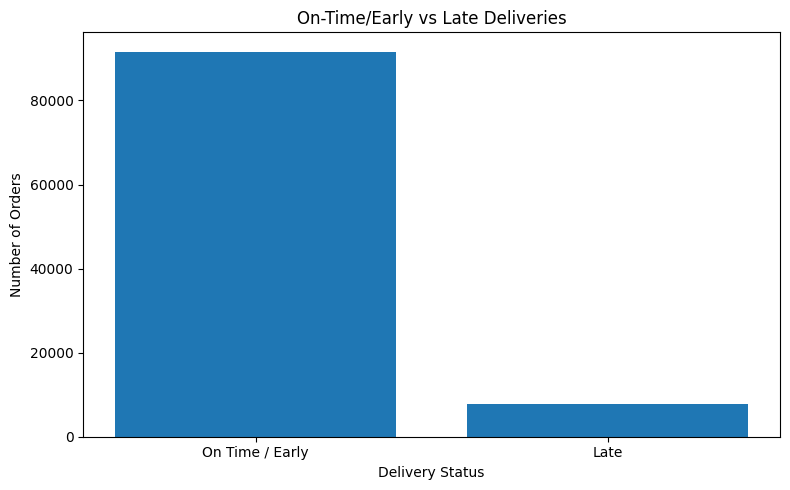

In [131]:
# Early vs Late Deliveries
plt.figure(figsize=(8, 5))

plt.bar(
    delivery_status_count.index,
    delivery_status_count.values
)

plt.title("On-Time/Early vs Late Deliveries")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

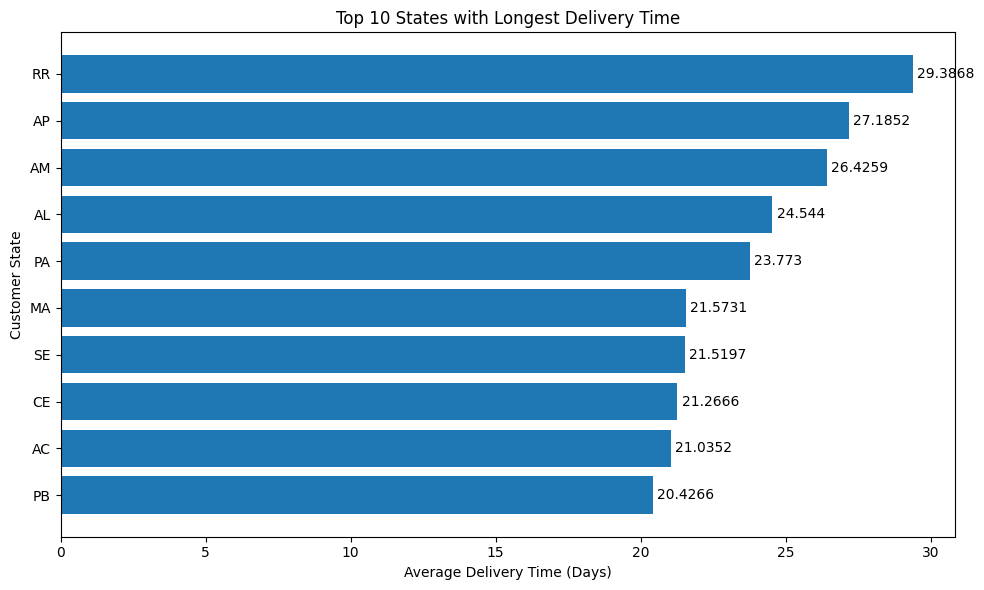

In [133]:
# Top 10 States with Longest Average Delivery Time

top_slowest_states = (
    state_delivery_time
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_slowest_states.index,
    top_slowest_states.values
)
plt.bar_label(bars, padding=3)

plt.title("Top 10 States with Longest Delivery Time")
plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("Customer State")

plt.tight_layout()

plt.show()

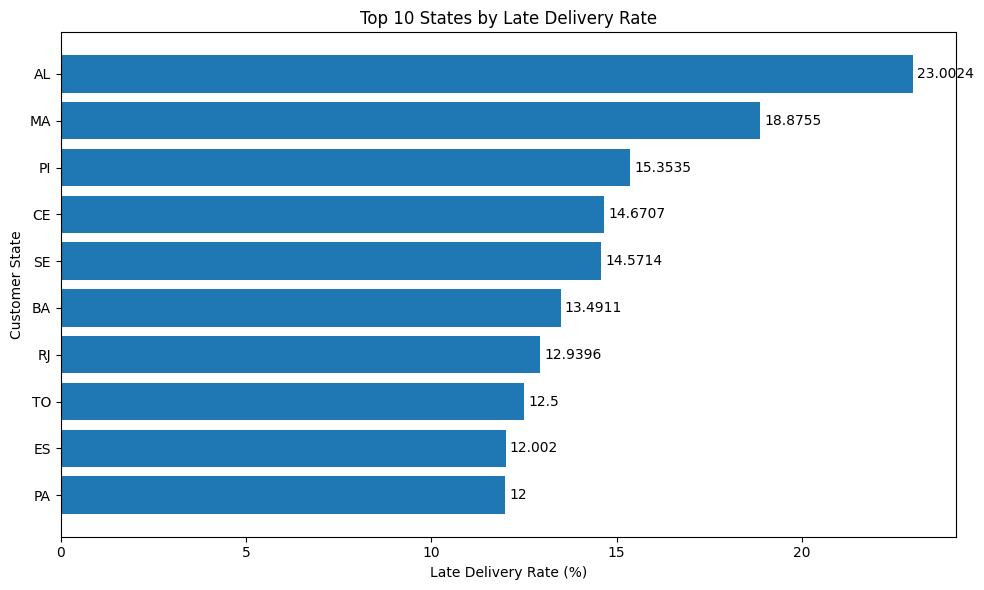

In [135]:
# Late Delivery Rate by State
state_late_rate = (
    delivery_data
    .groupby("customer_state")["delivery_status"]
    .apply(lambda x: (x == "Late").mean() * 100)
    .sort_values(ascending=False)
)

top_late_states = state_late_rate.head(10).sort_values()

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_late_states.index,
    top_late_states.values
)
plt.bar_label(bars, padding=3)

plt.title("Top 10 States by Late Delivery Rate")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Customer State")

plt.tight_layout()

plt.show()

# Review Analysis

In [136]:
# Basic Review Overview

total_reviews = len(reviews)

average_review_score = reviews["review_score"].mean()

median_review_score = reviews["review_score"].median()

print("Total Reviews:", f"{total_reviews:,}")
print("Average Review Score:", round(average_review_score, 2))
print("Median Review Score:", median_review_score)

Total Reviews: 99,224
Average Review Score: 4.09
Median Review Score: 5.0


In [137]:
# Count reviews for each score

review_distribution = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)

print(review_distribution)

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


In [ ]:
# Positive, Neutral and Negative Reviews
# Create satisfaction categories

reviews["satisfaction_level"] = np.select(
    [
        reviews["review_score"] <= 2,
        reviews["review_score"] == 3,
        reviews["review_score"] >= 4
    ],
    [
        "Negative",
        "Neutral",
        "Positive"
    ],
    default="Unknown"
)

satisfaction_distribution = (
    reviews["satisfaction_level"]
    .value_counts()
)

print(satisfaction_distribution)

satisfaction_level
Positive    76470
Negative    14575
Neutral      8179
Name: count, dtype: int64


In [139]:
# Positive Customer Satisfaction Rate
positive_review_rate = (
    reviews["satisfaction_level"]
    .eq("Positive")
    .mean()
    * 100
)

negative_review_rate = (
    reviews["satisfaction_level"]
    .eq("Negative")
    .mean()
    * 100
)

print("Positive Review Rate:", round(positive_review_rate, 2), "%")
print("Negative Review Rate:", round(negative_review_rate, 2), "%")

Positive Review Rate: 77.07 %
Negative Review Rate: 14.69 %


In [140]:
# Does Late Delivery Affect Review Scores?
# Merge delivery data with reviews

review_delivery = (
    delivery_data
    .merge(
        reviews[
            [
                "order_id",
                "review_score"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

review_delivery.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,customer_city,delivery_time_days,delivery_difference_days,delivery_status,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,SP,sao paulo,8.44,-7.11,On Time / Early,4
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,BA,barreiras,13.78,-5.36,On Time / Early,4
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,GO,vianopolis,9.39,-17.25,On Time / Early,5
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,RN,sao goncalo do amarante,13.21,-12.98,On Time / Early,5
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,SP,santo andre,2.87,-9.24,On Time / Early,5


In [141]:
# Now calculate the average review score for each delivery status.
# Average review score by delivery status

review_by_delivery_status = (
    review_delivery
    .groupby("delivery_status")["review_score"]
    .mean()
    .sort_values(ascending=False)
)

print(review_by_delivery_status)

delivery_status
On Time / Early    4.214315
Late               2.565172
Name: review_score, dtype: float64


In [142]:
# Review Score by Delivery Time
review_by_score = (
    review_delivery
    .groupby("review_score")["delivery_time_days"]
    .mean()
    .sort_index()
)

print(review_by_score)

review_score
1    21.311394
2    16.660571
3    14.261943
4    12.312309
5    10.688601
Name: delivery_time_days, dtype: float64


In [ ]:
# Average Review Score by Customer State
review_state_data = (
    reviews[
        [
            "order_id",
            "review_score"
        ]
    ]
    .merge(
        orders[
            [
                "order_id",
                "customer_id"
            ]
        ],
        on="order_id",
        how="inner"
    )
    .merge(
        customers[
            [
                "customer_id",
                "customer_state"
            ]
        ],
        on="customer_id",
        how="inner"
    )
)

state_review_score = (
    review_state_data
    .groupby("customer_state")["review_score"]
    .mean()
    .sort_values(ascending=False)
)

print(state_review_score)

# This helps us identify which customer locations have the highest and lowest satisfaction levels.

customer_state
AP    4.194030
AM    4.183673
PR    4.180032
SP    4.173951
MG    4.136172
RS    4.133321
MS    4.118785
RN    4.105809
MT    4.102990
TO    4.096774
SC    4.071764
DF    4.064711
RO    4.051587
AC    4.049383
GO    4.042490
ES    4.041667
PB    4.018832
PE    4.011543
PI    3.920570
RJ    3.874971
BA    3.860888
CE    3.851016
PA    3.849174
SE    3.808023
MA    3.764075
AL    3.751208
RR    3.608696
Name: review_score, dtype: float64


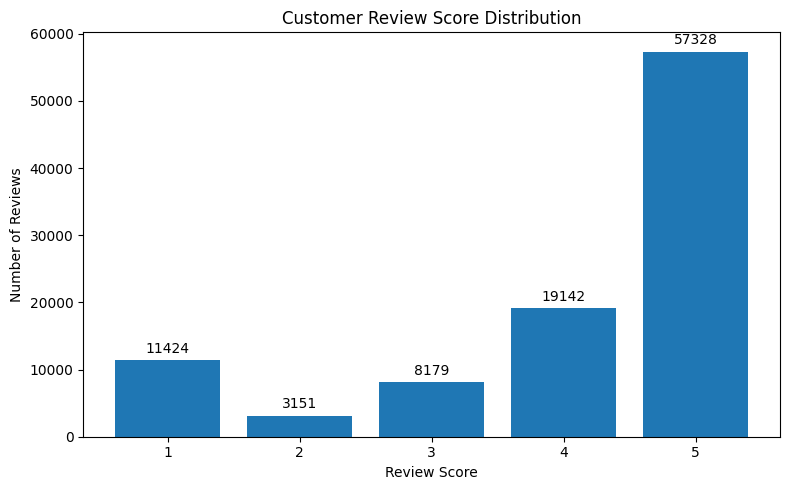

In [144]:
# Review Score Distribution

plt.figure(figsize=(8, 5))

bars  = plt.bar(
    review_distribution.index.astype(str),
    review_distribution.values
)
plt.bar_label(bars, padding=3)

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.show()

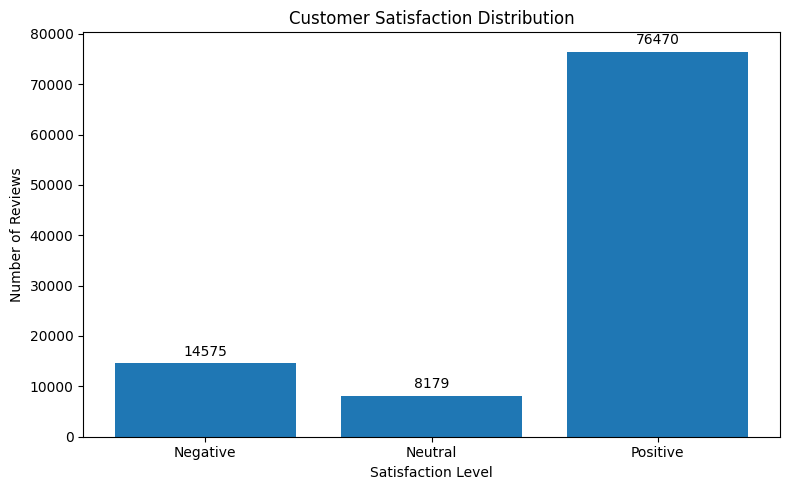

In [146]:
# Positive vs Neutral vs Negative Reviews
satisfaction_order = [
    "Negative",
    "Neutral",
    "Positive"
]

satisfaction_plot = (
    satisfaction_distribution
    .reindex(satisfaction_order)
    .fillna(0)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    satisfaction_plot.index,
    satisfaction_plot.values
)
plt.bar_label(bars, padding=3)

plt.title("Customer Satisfaction Distribution")
plt.xlabel("Satisfaction Level")
plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.show()

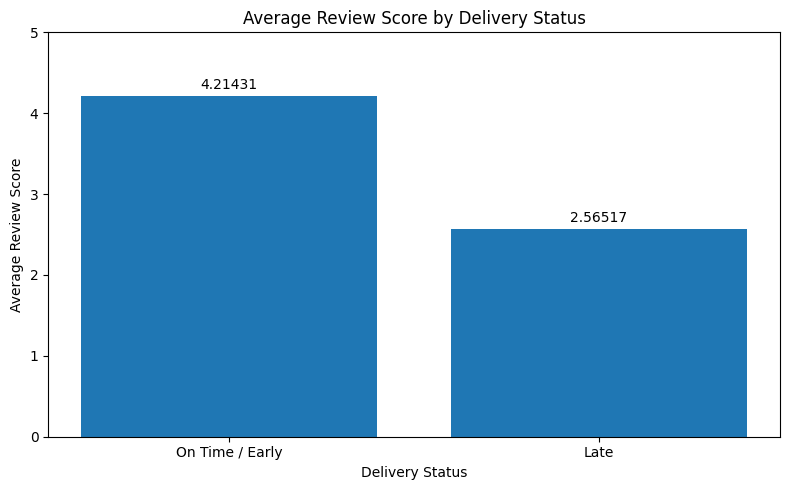

In [147]:
# Average Review Score: Late vs On-Time/Early

plt.figure(figsize=(8, 5))

bars = plt.bar(
    review_by_delivery_status.index,
    review_by_delivery_status.values
)
plt.bar_label(bars, padding=3)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")

plt.ylim(0, 5)

plt.tight_layout()

plt.show()

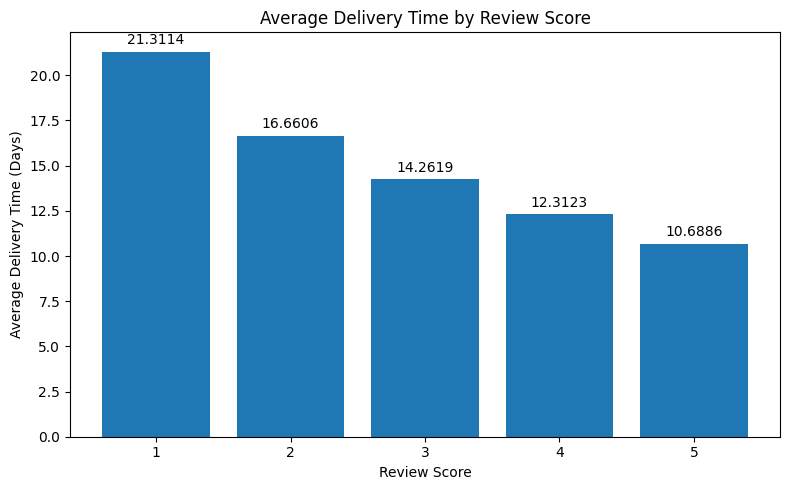

In [149]:
# Average Delivery Time by Review Score
plt.figure(figsize=(8, 5))

bars = plt.bar(
    review_by_score.index.astype(str),
    review_by_score.values
)
plt.bar_label(bars, padding=3)

plt.title("Average Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Time (Days)")

plt.tight_layout()

plt.show()

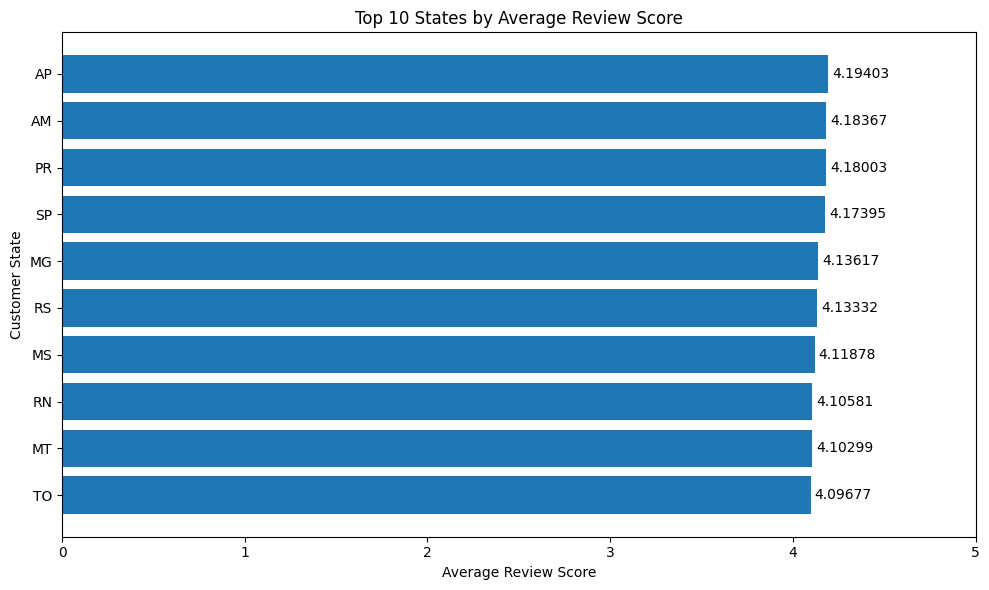

In [150]:
# Top States by Review Score
top_review_states = state_review_score.head(10).sort_values()

plt.figure(figsize=(10, 6))

bars =plt.barh(
    top_review_states.index,
    top_review_states.values
)
plt.bar_label(bars, padding=3)

plt.title("Top 10 States by Average Review Score")
plt.xlabel("Average Review Score")
plt.ylabel("Customer State")

plt.xlim(0, 5)

plt.tight_layout()

plt.show()

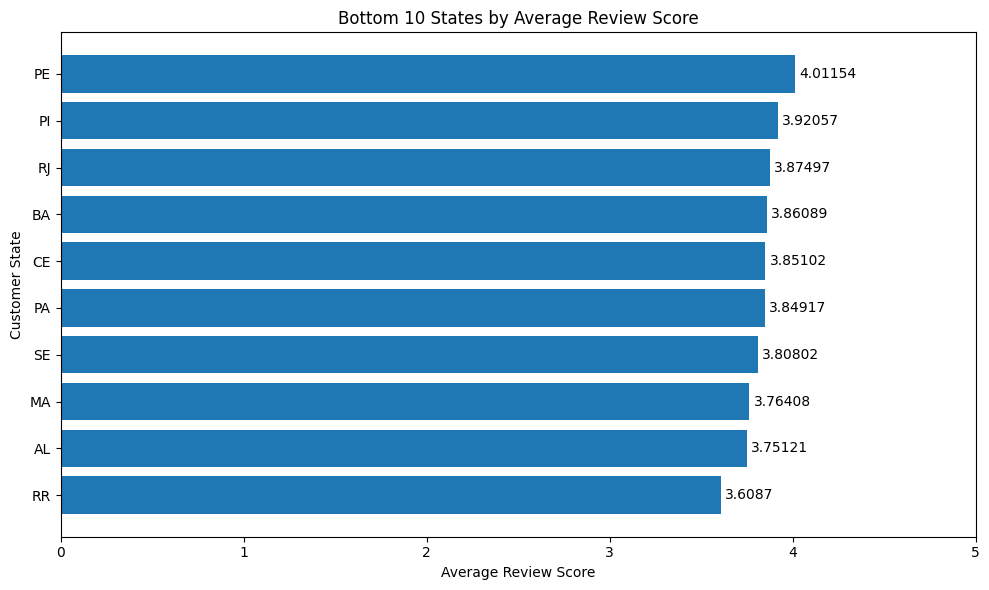

In [151]:
# Bottom States by Review Score
bottom_review_states = state_review_score.tail(10).sort_values()

plt.figure(figsize=(10, 6))

bars =plt.barh(
    bottom_review_states.index,
    bottom_review_states.values
)
plt.bar_label(bars, padding=3)

plt.title("Bottom 10 States by Average Review Score")
plt.xlabel("Average Review Score")
plt.ylabel("Customer State")

plt.xlim(0, 5)

plt.tight_layout()

plt.show()

# Advanced Relationship Analysis

In [152]:
# Delivery Time vs Review Score
# Correlation between delivery time and review score

delivery_review_corr = (
    review_delivery[
        ["delivery_time_days", "review_score"]
    ]
    .corr()
)

print(delivery_review_corr)

                    delivery_time_days  review_score
delivery_time_days            1.000000     -0.333803
review_score                 -0.333803      1.000000


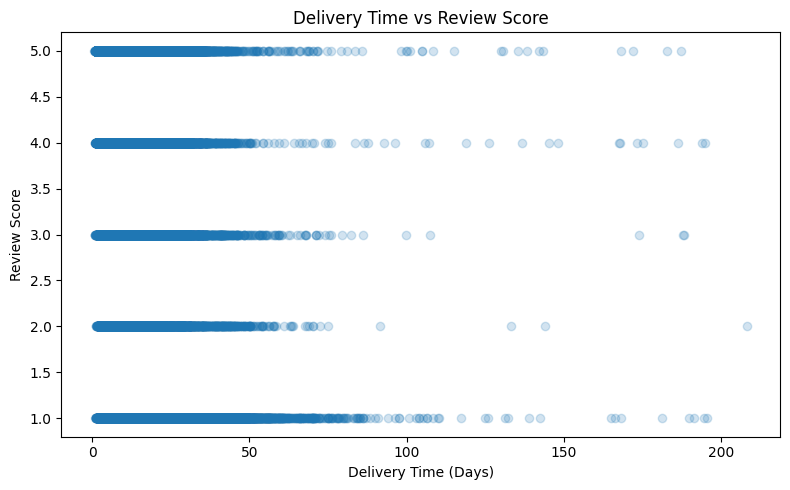

In [153]:
plt.figure(figsize=(8, 5))

plt.scatter(
    review_delivery["delivery_time_days"],
    review_delivery["review_score"],
    alpha=0.2
)

plt.title("Delivery Time vs Review Score")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Review Score")

plt.tight_layout()

plt.show()

The correlation between **delivery time and review score is -0.33**, which shows a **moderate negative relationship** between them. The negative value means that, in general, **customers who wait longer for their orders tend to give lower ratings**.

From the scatter plot, we can see that **shorter delivery times have many 4-star and 5-star reviews**, while orders with very long delivery times include more low ratings such as **1 or 2 stars**. However, the relationship is not extremely strong because customer ratings can also be affected by other factors like **product quality, wrong items, seller service, or product expectations**.

**Conclusion:** Faster delivery is associated with better customer satisfaction, while longer delivery times can negatively affect review scores.


In [154]:
# Order Value vs Review Score
# Calculate total order value

order_value = (
    items
    .groupby("order_id")["price"]
    .sum()
    .reset_index(name="order_value")
)

# Merge with reviews

order_review = (
    order_value
    .merge(
        reviews[["order_id", "review_score"]],
        on="order_id",
        how="inner"
    )
)

print(order_review.head())

                           order_id  order_value  review_score
0  00010242fe8c5a6d1ba2dd792cb16214        58.90             5
1  00018f77f2f0320c557190d7a144bdd3       239.90             4
2  000229ec398224ef6ca0657da4fc703e       199.00             5
3  00024acbcdf0a6daa1e931b038114c75        12.99             4
4  00042b26cf59d7ce69dfabb4e55b4fd9       199.90             5


In [155]:
# Correlation between order value and review score

order_review_corr = (
    order_review[
        ["order_value", "review_score"]
    ]
    .corr()
)

print(order_review_corr)

              order_value  review_score
order_value      1.000000     -0.039672
review_score    -0.039672      1.000000


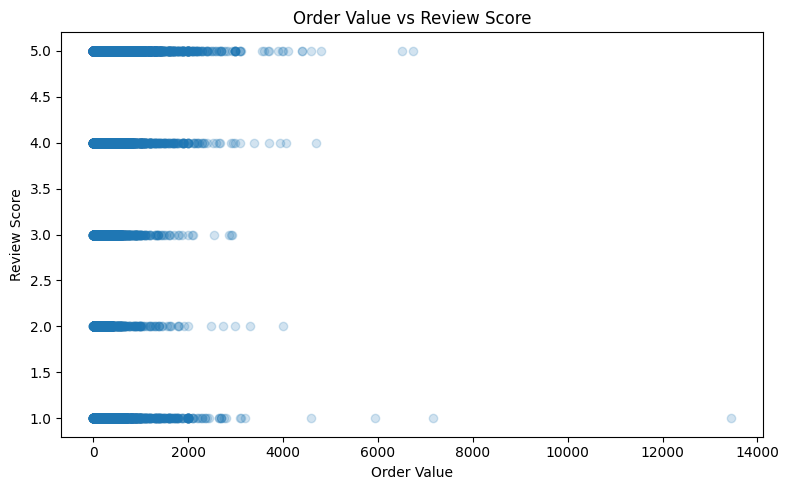

In [156]:
plt.figure(figsize=(8, 5))

plt.scatter(
    order_review["order_value"],
    order_review["review_score"],
    alpha=0.2
)

plt.title("Order Value vs Review Score")
plt.xlabel("Order Value")
plt.ylabel("Review Score")

plt.tight_layout()

plt.show()

The correlation between **order value and review score is approximately -0.04**, which shows an **extremely weak negative relationship**. In simple words, the **amount a customer spends does not have any meaningful effect on the review score**.

From the scatter plot, we can see that both **low-value and high-value orders can receive any rating from 1 to 5 stars**. Most orders are concentrated at lower order values, while only a few very expensive orders appear as outliers.

**Conclusion:** Unlike delivery time, **order value is not strongly related to customer satisfaction**. Spending more money does not necessarily mean a customer will give a higher or lower rating. Other factors, such as **delivery experience, product quality, and seller service**, are likely more important.


In [157]:
# Product Price vs Freight Value
# This analysis checks whether expensive products also have higher shipping costs.

# Correlation between price and freight value

price_freight_corr = (
    items[
        ["price", "freight_value"]
    ]
    .corr()
)

print(price_freight_corr)

                  price  freight_value
price          1.000000       0.414204
freight_value  0.414204       1.000000


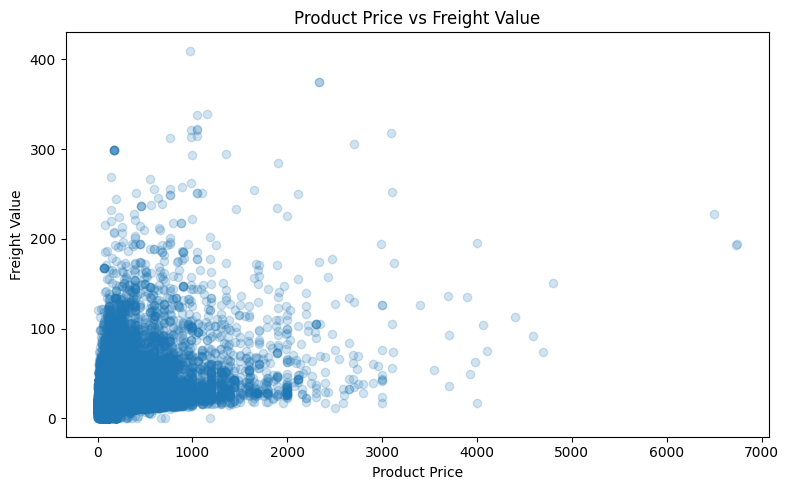

In [158]:
plt.figure(figsize=(8, 5))

plt.scatter(
    items["price"],
    items["freight_value"],
    alpha=0.2
)

plt.title("Product Price vs Freight Value")
plt.xlabel("Product Price")
plt.ylabel("Freight Value")

plt.tight_layout()

plt.show()

The correlation between **product price and freight value is 0.43**, which shows a **moderate positive relationship**. In simple words, **as the product price increases, the freight cost also tends to increase**, but the relationship is not very strong.

From the scatter plot, most products are concentrated at lower prices and lower freight values. However, there are some expensive products with both high and low freight costs. This means that **price alone does not decide the shipping cost**. Other factors, such as **product weight, size, delivery distance, and seller location**, can also affect freight charges.

**Conclusion:** More expensive products generally tend to have higher freight costs, but **product price is only one factor influencing freight value**.


In [159]:
# Product Weight vs Freight Value

# Create weight and freight dataset

weight_freight = (
    items[
        [
            "product_id",
            "freight_value"
        ]
    ]
    .merge(
        products[
            [
                "product_id",
                "product_weight_g"
            ]
        ],
        on="product_id",
        how="left"
    )
    .dropna()
)

# Correlation

weight_freight_corr = (
    weight_freight[
        [
            "product_weight_g",
            "freight_value"
        ]
    ]
    .corr()
)

print(weight_freight_corr)

                  product_weight_g  freight_value
product_weight_g          1.000000       0.610437
freight_value             0.610437       1.000000


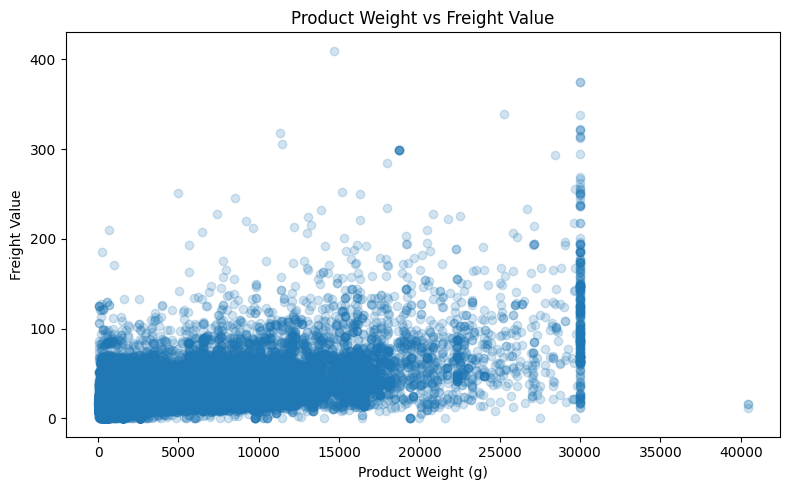

In [160]:
plt.figure(figsize=(8, 5))

plt.scatter(
    weight_freight["product_weight_g"],
    weight_freight["freight_value"],
    alpha=0.2
)

plt.title("Product Weight vs Freight Value")
plt.xlabel("Product Weight (g)")
plt.ylabel("Freight Value")

plt.tight_layout()

plt.show()

The correlation between **product weight and freight value is 0.60**, which shows a **moderately strong positive relationship**. In simple words, **heavier products generally have higher shipping costs**.

From the scatter plot, most products with lower weight have relatively low freight values. As the product weight increases, the freight value also tends to increase. However, the points are still spread out, meaning that **weight is not the only factor affecting shipping cost**.

Some heavy products have lower freight costs, while some lighter products have higher freight costs. This could depend on factors such as **delivery distance, product dimensions, seller location, and shipping method**.

**Conclusion:** Product weight has a stronger relationship with freight cost than product price. The result suggests that **heavier products generally cost more to ship**, making weight an important factor in determining freight value.


In [161]:
# Customer Spending vs Review Score
# Customer order value and review score

spending_review = (
    order_value
    .merge(
        reviews[
            [
                "order_id",
                "review_score"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

spending_review_corr = (
    spending_review[
        [
            "order_value",
            "review_score"
        ]
    ]
    .corr()
)

print(spending_review_corr)

              order_value  review_score
order_value      1.000000     -0.039672
review_score    -0.039672      1.000000


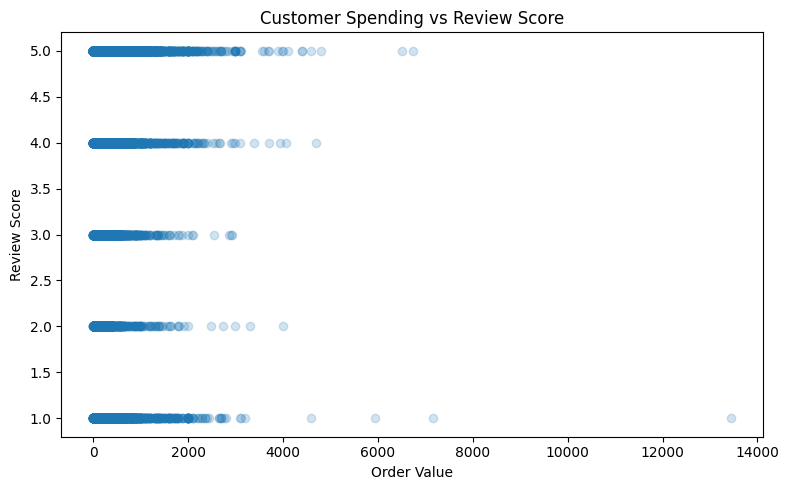

In [162]:
plt.figure(figsize=(8, 5))

plt.scatter(
    spending_review["order_value"],
    spending_review["review_score"],
    alpha=0.2
)

plt.title("Customer Spending vs Review Score")
plt.xlabel("Order Value")
plt.ylabel("Review Score")

plt.tight_layout()

plt.show()

The correlation between **customer spending (order value) and review score is approximately -0.04**, which shows an **extremely weak negative relationship**. In simple words, **how much a customer spends does not have a meaningful impact on the rating they give**.

From the scatter plot, we can see that both **low-value and high-value orders receive different ratings from 1 to 5 stars**. Most orders are concentrated at lower values, while only a few very expensive orders appear as outliers.

**Conclusion:** Customers who spend more money are **not necessarily more satisfied or less satisfied**. Order value has almost no relationship with review scores. Factors such as **delivery time, product quality, seller service, and whether the customer received what they expected** are likely more important in determining customer satisfaction.


In [163]:
# Payment Value vs Number of Installments
# Correlation between payment value and installments

payment_installment_corr = (
    payments[
        [
            "payment_value",
            "payment_installments"
        ]
    ]
    .corr()
)

print(payment_installment_corr)

                      payment_value  payment_installments
payment_value              1.000000              0.330811
payment_installments       0.330811              1.000000


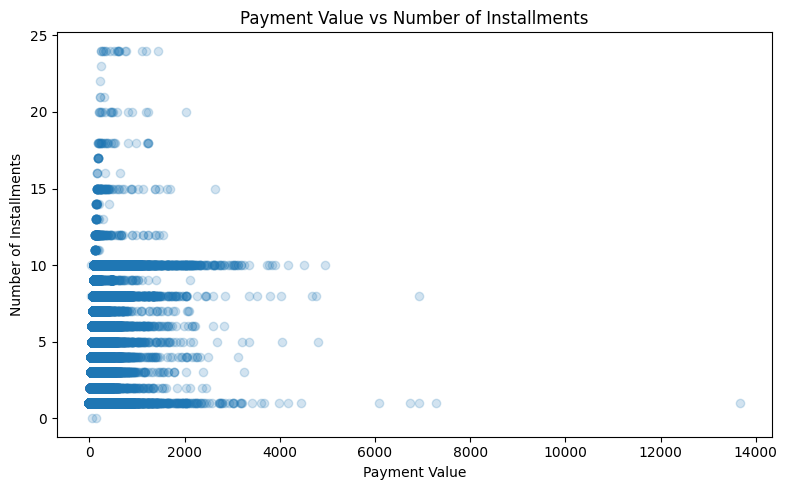

In [164]:
plt.figure(figsize=(8, 5))

plt.scatter(
    payments["payment_value"],
    payments["payment_installments"],
    alpha=0.2
)

plt.title("Payment Value vs Number of Installments")
plt.xlabel("Payment Value")
plt.ylabel("Number of Installments")

plt.tight_layout()

plt.show()

The correlation between **payment value and number of installments is 0.33**, which shows a **moderate positive relationship**. In simple words, **customers generally tend to use more installments when the payment amount is higher**.

From the scatter plot, we can see that most payments are concentrated at lower values, with customers using different numbers of installments. As the payment value increases, there is a general tendency for more installments, but the relationship is **not very strong**. Some customers make high-value payments with only a few installments, while others use many installments for relatively lower payments.

**Conclusion:** Higher payment values are somewhat associated with a higher number of installments, but **payment value is not the only factor that determines how many installments a customer chooses**.


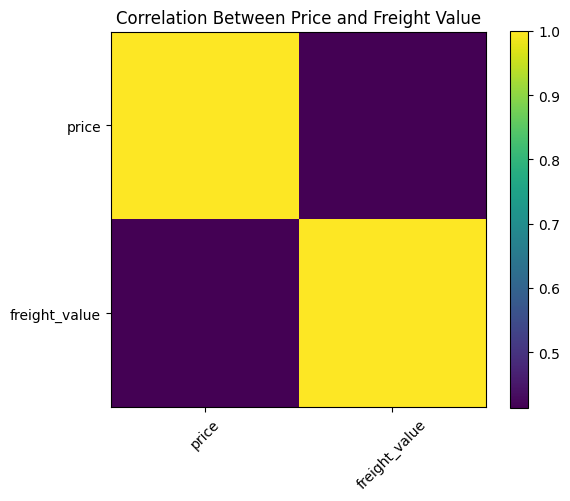

In [165]:
# Create a Correlation Heatmap
correlation_data = pd.DataFrame({
    "price": items["price"],
    "freight_value": items["freight_value"]
})

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(6, 5))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Between Price and Freight Value")

plt.tight_layout()

plt.show()

This **correlation heatmap** shows the relationship between **product price** and **freight value**.

The diagonal values are **1.0** because each variable has a perfect correlation with itself. The important relationship is between **price and freight value**, which is around **0.43**.

**Conclusion:** There is a **moderate positive relationship** between product price and freight value. In general, higher-priced products tend to have higher shipping costs, but the relationship is not strong enough to say that price alone determines the freight cost. Other factors like **product weight, dimensions, and delivery distance** also likely affect the freight value.


# Final Business Recommendations

Based on the overall data analysis, the following business recommendations can help improve sales, customer satisfaction, delivery performance, and overall business operations:

## 1. Improve Delivery Performance

The analysis shows a negative relationship between delivery time and review score. This means customers generally give lower ratings when delivery takes longer. The company should focus on reducing delivery delays, improving logistics, and identifying regions or sellers that have consistently slow delivery times.

## 2. Focus on Customer Satisfaction

Customer reviews are an important indicator of customer experience. Orders with faster and smoother delivery are more likely to receive better review scores. The company should investigate low-rated orders to understand whether the main reasons are delivery delays, product quality, seller performance, or other issues.

## 3. Monitor High-Value Orders

The analysis shows a weak negative relationship between order value and review score. This means expensive orders do not necessarily receive better reviews. High-value orders should receive extra attention because customers may have higher expectations when spending more money.

## 4. Optimize Shipping Costs

Product price and freight value have a moderate positive relationship. In general, more expensive products can also have higher shipping costs, but there are many exceptions. The company should review products with unusually high freight charges and look for better shipping or logistics options.

## 5. Consider Product Weight in Logistics Planning

Product weight also has a positive relationship with freight value. Heavier products generally cost more to ship, although the relationship is not perfect. The company can improve logistics planning by grouping products based on weight, size, and delivery location.

## 6. Improve Payment Experience

Credit cards are the most commonly used payment method, while some payment records have zero payment values or unusual installment values. These cases should be monitored to understand whether they are caused by vouchers, discounts, system issues, or special transactions.

## 7. Focus on Successful Order Completion

Most orders in the dataset were successfully delivered, which is a positive sign. However, canceled, unavailable, and other incomplete orders should be analyzed further to identify the main reasons behind them. Reducing these unsuccessful orders can directly improve revenue and customer satisfaction.

## 8. Identify High-Performing Products and Categories

The company should focus on product categories that generate high sales and revenue. At the same time, categories with low sales or poor customer reviews should be investigated to determine whether improvements in pricing, product quality, marketing, or availability are needed.

## 9. Monitor Seller Performance

Since sellers directly affect product availability and delivery performance, the company should compare sellers based on sales, number of orders, delivery performance, and customer review scores. High-performing sellers can be used as benchmarks, while sellers with poor performance may need additional support or monitoring.

## 10. Improve Customer Retention

The customer purchase frequency analysis shows that most customers make only one purchase. This suggests that customer retention can be improved. The company could introduce loyalty programs, personalized offers, discounts, or recommendations to encourage customers to make repeat purchases.

## 11. Investigate Extreme Values Instead of Removing Them Automatically

The dataset contains several outliers in product prices, freight values, payment values, and product dimensions. These values may represent genuine expensive products or unusual orders rather than errors. Therefore, they should be investigated before being removed from the analysis.

## Overall Recommendation

The business is performing well in terms of successful order delivery, but there are clear opportunities to improve customer retention, delivery speed, logistics costs, seller performance, and customer satisfaction. The strongest area for improvement is understanding the factors that lead to low review scores and long delivery times. By improving these areas and continuously monitoring important KPIs such as revenue, delivery time, review score, freight cost, cancellation rate, and repeat customers, the business can make better data-driven decisions and improve its overall performance.

If we go in numbers business is operationally strong, with approximately 97% of orders successfully delivered and an overall average review score of 4.09. However, customer retention is low, with only around 3.12% of customers making repeat purchases. Delivery performance appears to be one of the biggest drivers of customer satisfaction, as late deliveries have an average review score of only 2.57 compared with 4.21 for on-time or early deliveries. The business could improve customer retention and satisfaction by reducing delivery delays, especially in states with longer delivery times, while also using loyalty programs and personalized offers to encourage repeat purchases.